In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import yaml

In [2]:
TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAMES = ["number_of_trees__v2", "number_of_trees_aupr"]
METRICS = ["TT__auroc", "TL__auroc", "LT__auroc", "TT__auprc", "TL__auprc", "LT__auprc"]
PATH_OUT = Path.cwd().parents[1] / "results" / "number_of_trees.csv"
DIR_FIGURES = Path.cwd().parents[1] / "results" / "number_of_trees"
PATH_NAME_REPLACEMENTS_CONFIG = Path.cwd().parents[1] / "config" / "renaming.yml"
PATH_LOCAL_RCPARAMS = Path.cwd().parents[1] / "config" / "rc_params.yml"

# \textwidth and \columnwidth in AAAI layout (printed by LaTeX)
TEXT_WIDTH = 7.00137
COLUMN_WIDTH = 3.31314
HALF_COLUMN_WIDTH = COLUMN_WIDTH / 2 - 0.001  # Some small margin

In [3]:
renaming = yaml.safe_load(PATH_NAME_REPLACEMENTS_CONFIG.read_text())
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update(yaml.safe_load(PATH_LOCAL_RCPARAMS.read_text()))
plt.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (HALF_COLUMN_WIDTH,) * 2,
        "font.size": 7,
        "figure.titlesize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 5,  # Warning: must be expanded in inkscape
        "lines.linewidth": 1,
        "lines.markersize": 3,
    }
)
print(plt.rcParams["text.latex.preamble"])


\usepackage{times}
\newcommand{\asterism}{\smash{ \raisebox{-.5ex}{ \setlength{\tabcolsep}{-.5pt} \begin{tabular}{@{}cc@{}} \multicolumn2c*\\[-2ex]*&* \end{tabular}}}}


In [4]:
def get_metric_histories(client, runs_df, metric_names):
    from itertools import product
    from tqdm import tqdm

    metric_histories = []

    for (_, run), metric_name in tqdm(
        product(runs_df.iterrows(), metric_names),
        total=len(runs_df) * len(metric_names),
        desc="Fetching metric histories",
    ):
        if run.get("data.metrics." + metric_name, np.nan) == np.nan:
            continue
        # Fetch metric history for the run and metric name
        metric_history = client.get_metric_history(
            run_id=run["info.run_id"],
            key=metric_name,
        )
        for metric in metric_history:
            metric_histories.append(
                {
                    "run_id": run["info.run_id"],
                    "metric": metric.key,
                    "value": metric.value,
                    "timestamp": metric.timestamp,
                    "step": metric.step,
                    "estimator": run["data.tags.estimator"],
                    "dataset": run["data.tags.dataset"],
                    "fold_name": run["data.tags.fold_name"],
                    "validation_setting": run["data.tags.validation_setting"],
                }
            )

    return pd.DataFrame(metric_histories)

In [5]:
if PATH_OUT.exists():
    print(f"File {PATH_OUT} already exists. Loading existing data.")
    metric_histories_df = pd.read_csv(PATH_OUT)
else:
    import mlflow
    mlflow.set_tracking_uri(TRACKING_URI)
    print(mlflow.get_tracking_uri())
    # runs_df = fetch_runs(EXPERIMENT_NAMES)
    client = mlflow.tracking.MlflowClient(tracking_uri=TRACKING_URI)
    runs_list = []
    next_page_token = None
    while True:
        runs_page_list = client.search_runs(
            filter_string="attributes.status = 'FINISHED'",
            order_by=["start_time desc"],
            max_results=1000,  # Too many results can cause issues
            run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY,
            # experiment_names=experiment_names,
            experiment_ids=[10, 9],
            page_token=next_page_token,
        )
        runs_list.extend(runs_page_list)
        print(f"Fetched {len(runs_page_list)} runs, total: {len(runs_list)}")
        if not runs_page_list.token:
            break
        next_page_token = runs_page_list.token

    runs_df = pd.json_normalize([r.to_dictionary() for r in runs_list])

    metric_histories_df = get_metric_histories(client, runs_df, METRICS)
    PATH_OUT.parent.mkdir(parents=True, exist_ok=True)
    metric_histories_df.to_csv(PATH_OUT, index=False)


File c:\appsecurityexcluded\bipartite_forests_paper\experiments\results\number_of_trees.csv already exists. Loading existing data.


In [6]:
if not PATH_OUT.exists():
    display(runs_df.head())
metric_histories_df

,run_id,metric,value,timestamp,step,estimator,dataset,fold_name,validation_setting
0,562a1a29ac6b45ad9b2aaba8c17bb649,TT__auprc,0.076096,1753841540356,1,bictr,mirtarbase,TT_75__3,TT_75
1,562a1a29ac6b45ad9b2aaba8c17bb649,TT__auprc,0.077765,1753841540356,2,bictr,mirtarbase,TT_75__3,TT_75
2,562a1a29ac6b45ad9b2aaba8c17bb649,TT__auprc,0.078908,1753841540356,3,bictr,mirtarbase,TT_75__3,TT_75
3,562a1a29ac6b45ad9b2aaba8c17bb649,TT__auprc,0.079716,1753841540356,4,bictr,mirtarbase,TT_75__3,TT_75
4,562a1a29ac6b45ad9b2aaba8c17bb649,TT__auprc,0.080206,1753841540356,5,bictr,mirtarbase,TT_75__3,TT_75
...,...,...,...,...,...,...,...,...,...
235435,ccce649a9e8e41b18b1cf1002fcf9710,LT__auroc,0.801087,1753567806601,96,oxytrees,dpi_n,TT__0,TT
235436,ccce649a9e8e41b18b1cf1002fcf9710,LT__auroc,0.800656,1753567806601,115,oxytrees,dpi_n,TT__0,TT
235437,ccce649a9e8e41b18b1cf1002fcf9710,LT__auroc,0.800115,1753567806601,138,oxytrees,dpi_n,TT__0,TT
235438,ccce649a9e8e41b18b1cf1002fcf9710,LT__auroc,0.799766,1753567806601,166,oxytrees,dpi_n,TT__0,TT


In [7]:
# Considering LT and TL together
metric_histories_df["masking_percent"] = (
    metric_histories_df["validation_setting"]
    .str.extract(r"_(\d+)$")
    .astype(float)
    .fillna(0)
)
metric_histories_df[["validation_setting", "metric"]] = metric_histories_df[
    "metric"
].str.rsplit("__", n=1, expand=True)

# The fold name will keep the original setting info
metric_histories_df["fold_name"] = (
    metric_histories_df["validation_setting"] + "__" + metric_histories_df["fold_name"]
)
metric_histories_df = metric_histories_df.replace(
    {"validation_setting": {"LT": "LT+TL", "TL": "LT+TL"}}
)

In [8]:
# Renaming
metric_histories_df = metric_histories_df.replace(
    {
        "estimator": renaming["estimator"],
        "dataset": renaming["dataset"],
        "metric": renaming["metric"],
        "validation_setting": renaming["validation_setting"],
    }
)

In [9]:
metric_histories_df

,run_id,metric,value,timestamp,step,estimator,dataset,fold_name,validation_setting,masking_percent
0,562a1a29ac6b45ad9b2aaba8c17bb649,AUPRC,0.076096,1753841540356,1,BICTR,miRTarBase,TT__TT_75__3,Inductive,75.0
1,562a1a29ac6b45ad9b2aaba8c17bb649,AUPRC,0.077765,1753841540356,2,BICTR,miRTarBase,TT__TT_75__3,Inductive,75.0
2,562a1a29ac6b45ad9b2aaba8c17bb649,AUPRC,0.078908,1753841540356,3,BICTR,miRTarBase,TT__TT_75__3,Inductive,75.0
3,562a1a29ac6b45ad9b2aaba8c17bb649,AUPRC,0.079716,1753841540356,4,BICTR,miRTarBase,TT__TT_75__3,Inductive,75.0
4,562a1a29ac6b45ad9b2aaba8c17bb649,AUPRC,0.080206,1753841540356,5,BICTR,miRTarBase,TT__TT_75__3,Inductive,75.0
...,...,...,...,...,...,...,...,...,...,...
235435,ccce649a9e8e41b18b1cf1002fcf9710,AUROC,0.801087,1753567806601,96,Oxytrees,DPI-N,LT__TT__0,Semi-inductive,0.0
235436,ccce649a9e8e41b18b1cf1002fcf9710,AUROC,0.800656,1753567806601,115,Oxytrees,DPI-N,LT__TT__0,Semi-inductive,0.0
235437,ccce649a9e8e41b18b1cf1002fcf9710,AUROC,0.800115,1753567806601,138,Oxytrees,DPI-N,LT__TT__0,Semi-inductive,0.0
235438,ccce649a9e8e41b18b1cf1002fcf9710,AUROC,0.799766,1753567806601,166,Oxytrees,DPI-N,LT__TT__0,Semi-inductive,0.0


In [10]:
index_cols = [
    "validation_setting",
    "masking_percent",
    "dataset",
    "metric",
    "estimator",
    "fold_name",
    "step",
]

normalized_scores = metric_histories_df.set_index(index_cols)["value"]

# last_score = normalized_scores.groupby(
#     normalized_scores.index.droplevel("step").names  # All but the step level
# ).agg(
#     lambda x: x.xs(
#         x.index.get_level_values("step").max(),
#         level="step",
#     )
# )
last_score = normalized_scores.xs(200, level="step")
display(last_score)

normalized_scores /= last_score
display(normalized_scores)

# last_step = normalized_scores.reset_index("step", drop=False)["step"].groupby(level=index_cols[:-1]).idxmax()
#
# display(last_step)
# last_value = normalized_scores.loc[last_step]
# print("last value")
# display(last_value)

validation_setting  masking_percent  dataset     metric  estimator  fold_name   
Inductive           75.0             miRTarBase  AUPRC   BICTR      TT__TT_75__3    0.093387
Semi-inductive      75.0             miRTarBase  AUPRC   BICTR      TL__TT_75__3    0.182552
                                                                    LT__TT_75__3    0.114426
Inductive           75.0             miRTarBase  AUPRC   BICTR      TT__TT_75__2    0.100933
Semi-inductive      75.0             miRTarBase  AUPRC   BICTR      TL__TT_75__2    0.200467
                                                                                      ...   
                    0.0              DPI-N       AUROC   BICTR      TL__TT__0       0.961800
                                                                    LT__TT__0       0.833582
Inductive           0.0              DPI-N       AUROC   Oxytrees   TT__TT__0       0.309677
Semi-inductive      0.0              DPI-N       AUROC   Oxytrees   TL__TT__0     

validation_setting  masking_percent  dataset     metric  estimator  fold_name     step
Inductive           75.0             miRTarBase  AUPRC   BICTR      TT__TT_75__3  1       0.814845
                                                                                  2       0.832725
                                                                                  3       0.844963
                                                                                  4       0.853616
                                                                                  5       0.858865
                                                                                            ...   
Semi-inductive      0.0              DPI-N       AUROC   Oxytrees   LT__TT__0     96      1.002801
                                                                                  115     1.002262
                                                                                  138     1.001584
                      

In [11]:
normalized_scores.loc[normalized_scores.index.duplicated(keep=False)].sort_index()

Series([], Name: value, dtype: float64)

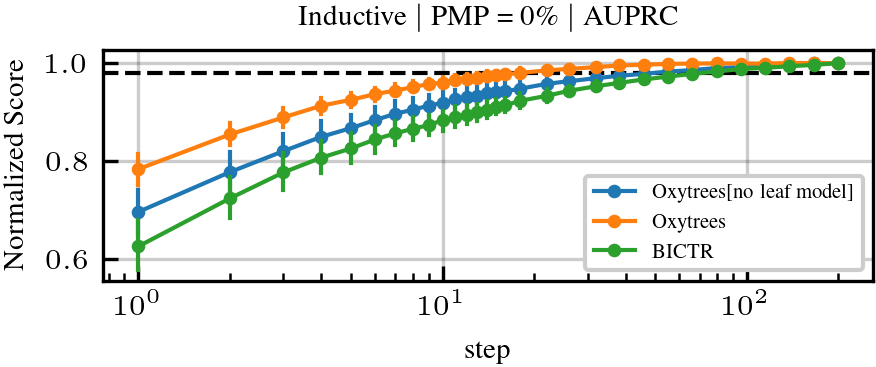

<Figure size 496.671x496.671 with 0 Axes>

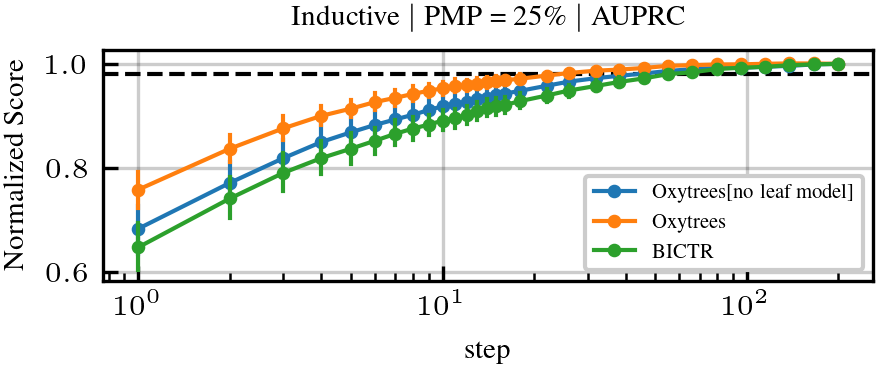

<Figure size 496.671x496.671 with 0 Axes>

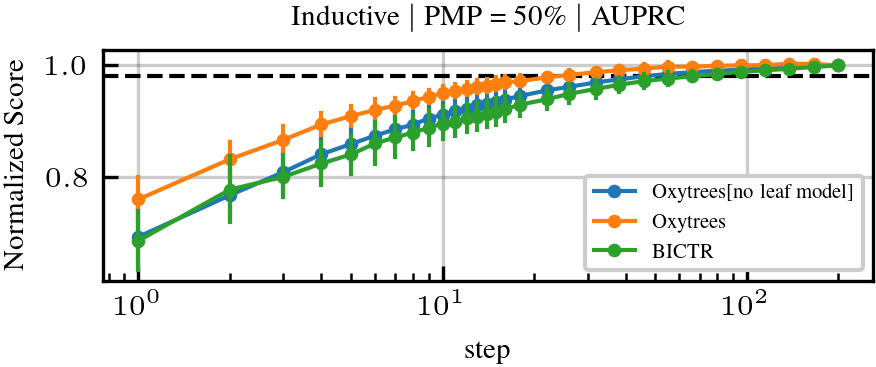

<Figure size 496.671x496.671 with 0 Axes>

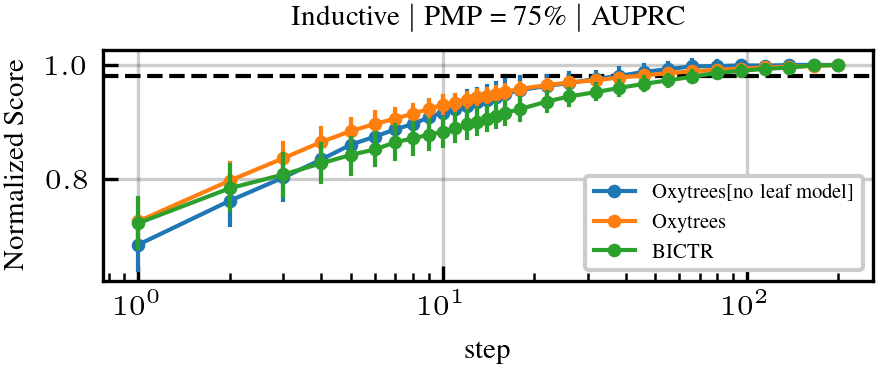

<Figure size 496.671x496.671 with 0 Axes>

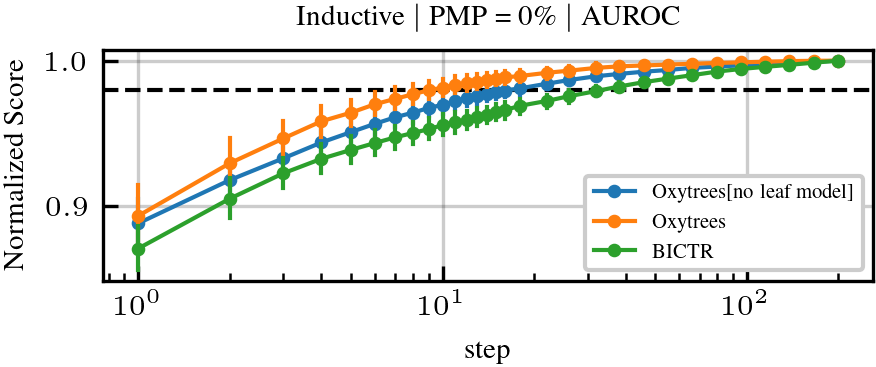

<Figure size 496.671x496.671 with 0 Axes>

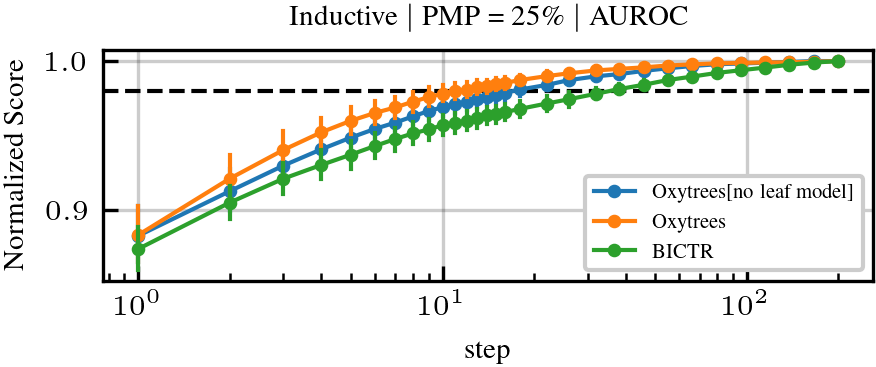

<Figure size 496.671x496.671 with 0 Axes>

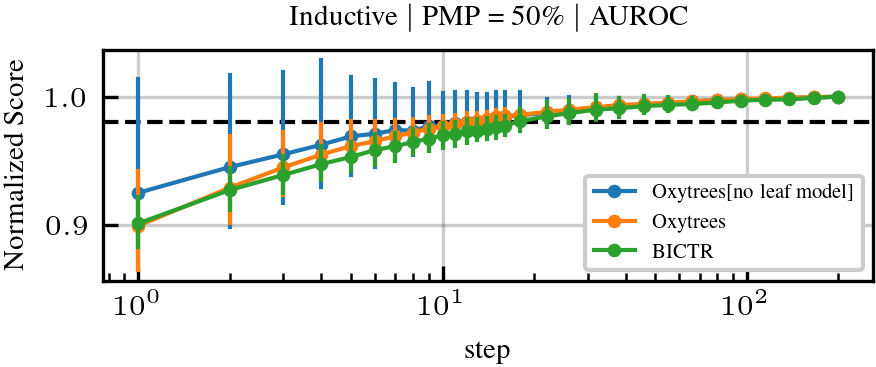

<Figure size 496.671x496.671 with 0 Axes>

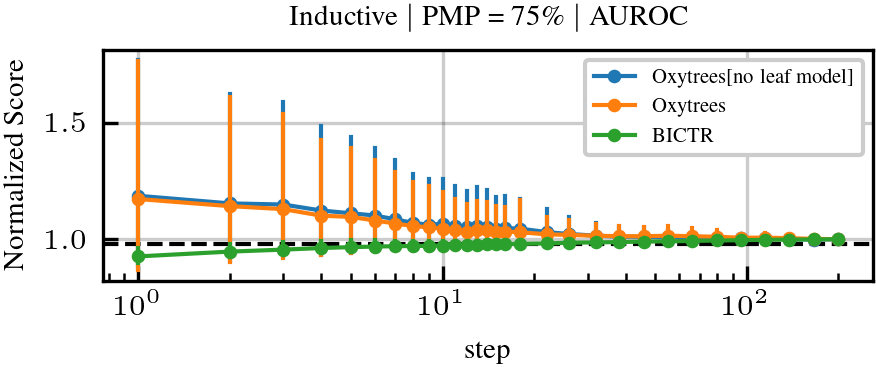

<Figure size 496.671x496.671 with 0 Axes>

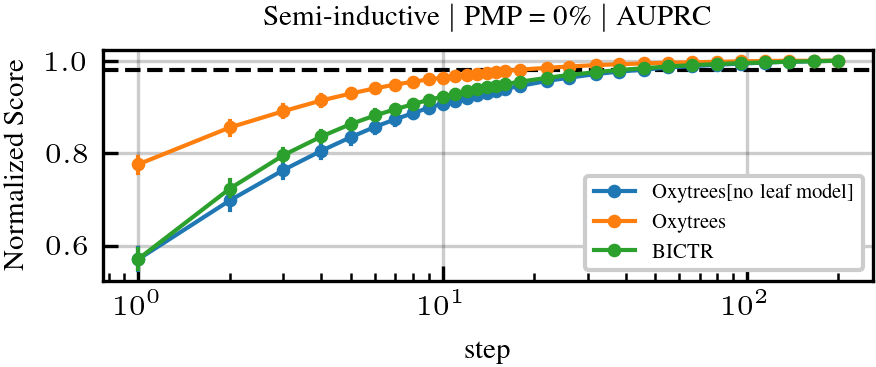

<Figure size 496.671x496.671 with 0 Axes>

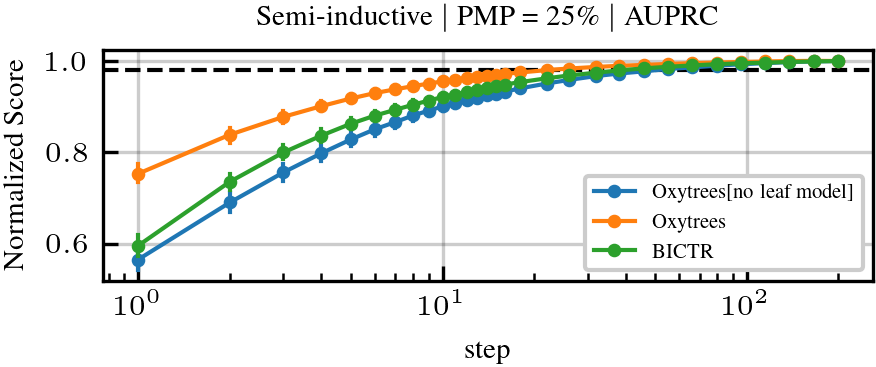

<Figure size 496.671x496.671 with 0 Axes>

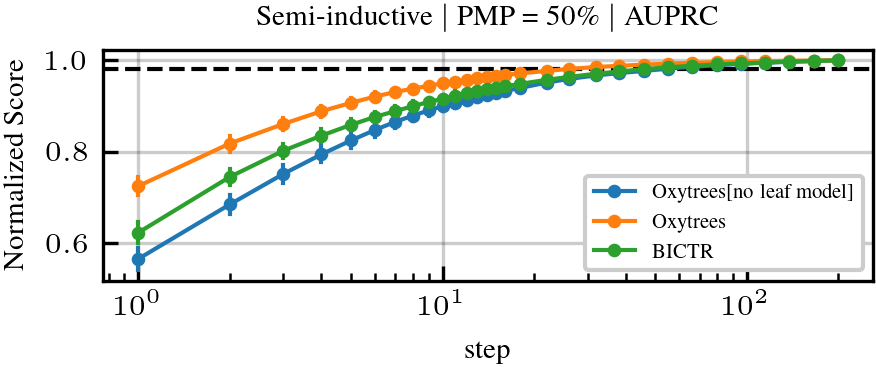

<Figure size 496.671x496.671 with 0 Axes>

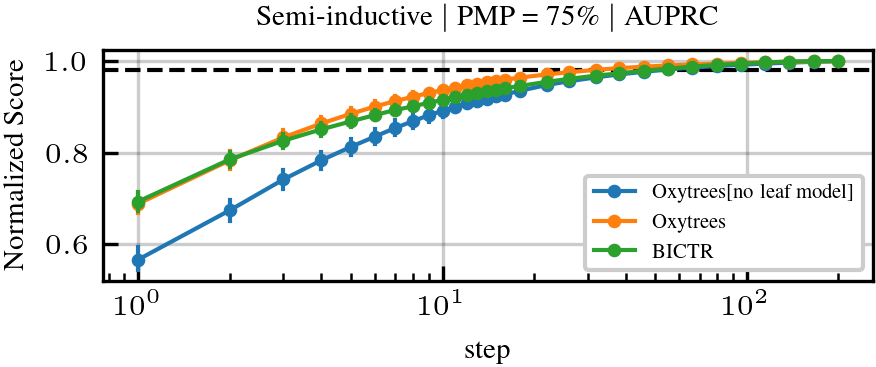

<Figure size 496.671x496.671 with 0 Axes>

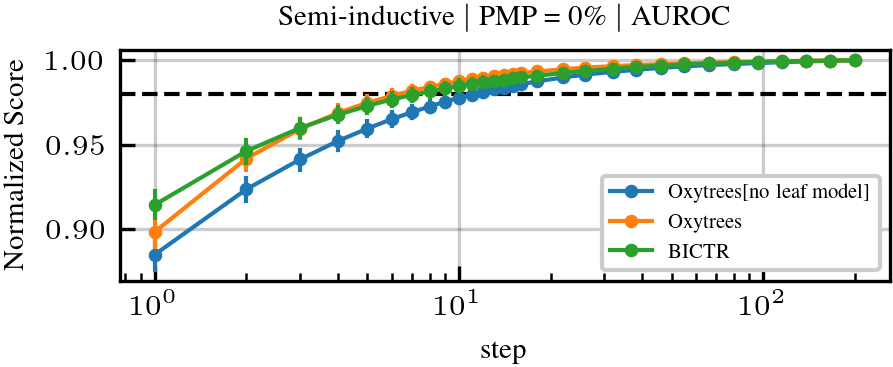

<Figure size 496.671x496.671 with 0 Axes>

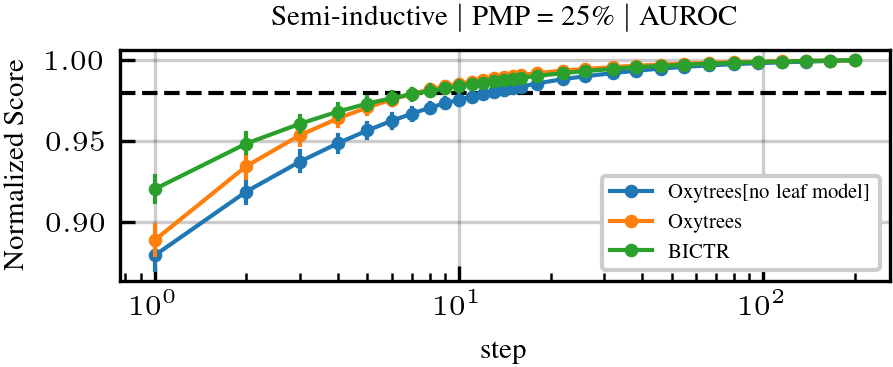

<Figure size 496.671x496.671 with 0 Axes>

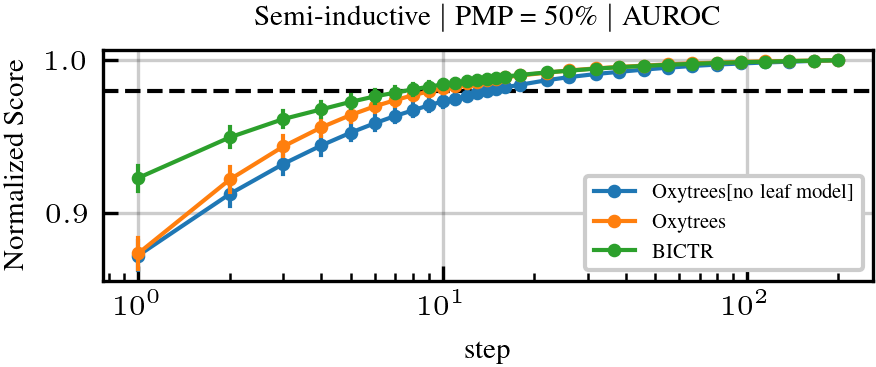

<Figure size 496.671x496.671 with 0 Axes>

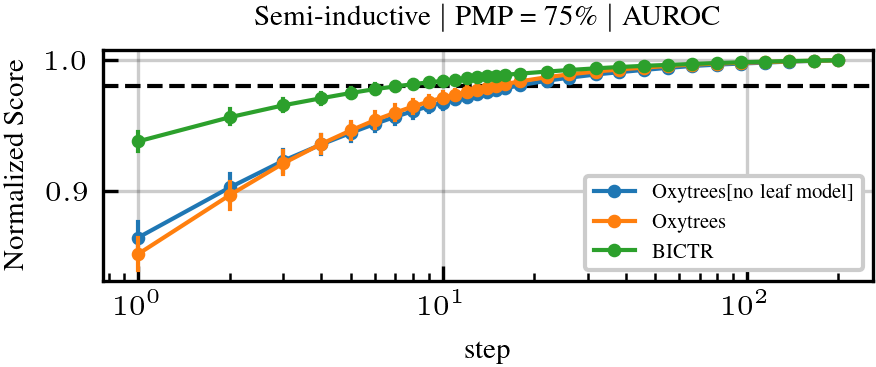

<Figure size 496.671x496.671 with 0 Axes>

In [12]:
TARGET_PERCENT = 0.98
figsize = (COLUMN_WIDTH, 1)

# groupby_cols defines the numbers in the templates below
groupby_cols = ["validation_setting", "metric", "masking_percent"]  
TITLE_TEMPLATE = "{0} $\\mid$ PMP = {2:.0f}\\% $\\mid$ {1}"
FILENAME_TEMPLATE = "{0}_{2:02.0f}_{1}"
hue_order = ("Oxytrees[no leaf model]", "Oxytrees", "BICTR")

OUTDIR = DIR_FIGURES / "raw_number_of_trees"
OUTDIR.mkdir(parents=True, exist_ok=True)

for name, group in normalized_scores.groupby(groupby_cols):
    plt.figure(figsize=figsize)
    plt.axhline(TARGET_PERCENT, color="k", linestyle="--", linewidth=1)
    sns.pointplot(
        data=group.reset_index(),
        x="step",
        y="value",
        hue="estimator",
        native_scale=True,
        capsize=0,
        linewidth=1,
        hue_order=hue_order,
    )
    plt.xscale("log")
    plt.legend(title=None)
    plt.title(TITLE_TEMPLATE.format(*name))
    plt.ylabel(f"Normalized Score")
    plt.grid()
    # plt.xticks(np.arange(1, group.index.get_level_values("step").max() + 1, 20))
    plt.xticks(minor=False)
    plt.savefig(OUTDIR / f"{FILENAME_TEMPLATE.format(*name)}.pdf")
    plt.show()
    plt.clf()

In [13]:
def get_interpolated_n_trees(group, target_scores):
    """
    Calculate the number of trees needed to reach given scores.
    """
    x = np.maximum.accumulate(group.values)  # Ensure non-decreasing order
    y = group.index.get_level_values("step").values
    n_trees = np.interp(target_scores, x, y)
    return pd.Series(n_trees, index=target_scores).rename_axis("target_score")


target_scores = [0.90, 0.95, 0.96, 0.97, 0.98, 0.99]

interpolated_n_trees = normalized_scores.groupby(
    level=normalized_scores.index.droplevel("step").names
).apply(get_interpolated_n_trees, target_scores=target_scores).rename("expected_n_trees")

display(interpolated_n_trees)

validation_setting  masking_percent  dataset     metric  estimator                fold_name     target_score
Inductive           0.0              DPI-E       AUPRC   BICTR                    TT__TT__0     0.90             43.150336
                                                                                                0.95             75.155757
                                                                                                0.96             88.628201
                                                                                                0.97            104.939567
                                                                                                0.98            127.762806
                                                                                                                   ...    
Semi-inductive      75.0             miRTarBase  AUROC   Oxytrees[no leaf model]  TL__TT_75__3  0.95             18.235091
                              

In [14]:
def format_p_value(p, alpha=0.05):
    if p > alpha:
        return f"p \\approx {p:.2g}"

    n_decimals = int(np.ceil(-np.log10(p)))
    pvalue_noexp = int(np.ceil(p * 10**n_decimals))

    if n_decimals == 1:
        return f"p < 0.{pvalue_noexp:.0f}"
    if pvalue_noexp == 10:
        short_pvalue_str = f"10^{{-{n_decimals - 1}}}"
    elif pvalue_noexp == 1:
        short_pvalue_str = f"10^{{-{n_decimals}}}"
    else:
        short_pvalue_str = f"{pvalue_noexp} \\cdot 10^{{-{n_decimals}}}"
    pvalue_eq = f"p < {short_pvalue_str}"
    return pvalue_eq

BICTR vs Oxytrees: WilcoxonResult(statistic=1.0, pvalue=0.0001220703125)
beta_hat=0.41695741203041436, se_beta=0.03424552100221658
linregress: LinregressResult(slope=0.3118630226673188, intercept=9.094385150406179, rvalue=0.7473405603955368, pvalue=0.0013624865027595135, stderr=0.07690068312162315, intercept_stderr=6.019880288175132)


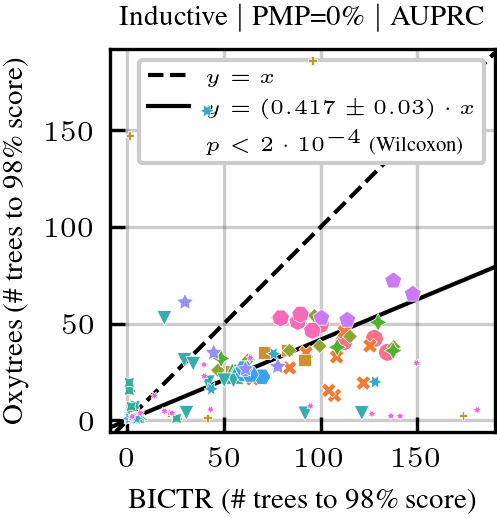

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=9.0, pvalue=0.00201416015625)
beta_hat=0.5907060106780795, se_beta=0.054858302874493114
linregress: LinregressResult(slope=0.4384613683733103, intercept=13.174551206742095, rvalue=0.6969036277374562, pvalue=0.003886464154396426, stderr=0.12514280688390966, intercept_stderr=9.796333215608684)


<Figure size 496.671x496.671 with 0 Axes>

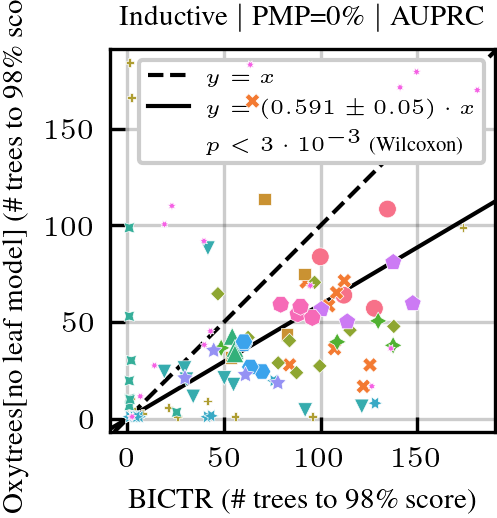

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=20.0, pvalue=0.02154541015625)
beta_hat=1.2565122933864208, se_beta=0.18448270515195114
linregress: LinregressResult(slope=0.44473848132843247, intercept=30.357523795415187, rvalue=0.2949792245607196, pvalue=0.28582815530497757, stderr=0.39955259986134095, intercept_stderr=13.643290675819438)


<Figure size 496.671x496.671 with 0 Axes>

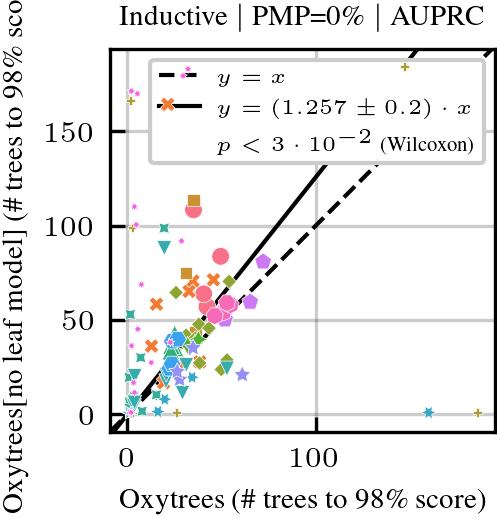

c:\appsecurityexcluded\bipartite_forests_paper\experiments\env_new\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Figure size 496.671x496.671 with 0 Axes>

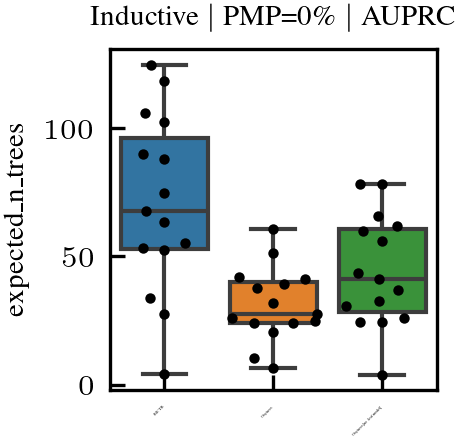

BICTR vs Oxytrees: WilcoxonResult(statistic=5.0, pvalue=0.0006103515625)
beta_hat=0.4740875501131356, se_beta=0.0362824145514125
linregress: LinregressResult(slope=0.3601048142282363, intercept=9.833911054667233, rvalue=0.7968234518173888, pvalue=0.0003760805849713666, stderr=0.07573290852222624, intercept_stderr=5.833709231291687)


<Figure size 496.671x496.671 with 0 Axes>

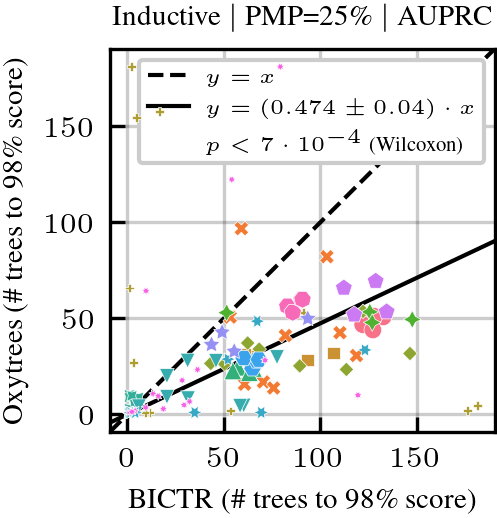

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=15.0, pvalue=0.00836181640625)
beta_hat=0.6181637043355078, se_beta=0.06354692540066166
linregress: LinregressResult(slope=0.460617705982766, intercept=13.59235083095481, rvalue=0.679328191069286, pvalue=0.005345201256451135, stderr=0.13800267177053582, intercept_stderr=10.630351797652388)


<Figure size 496.671x496.671 with 0 Axes>

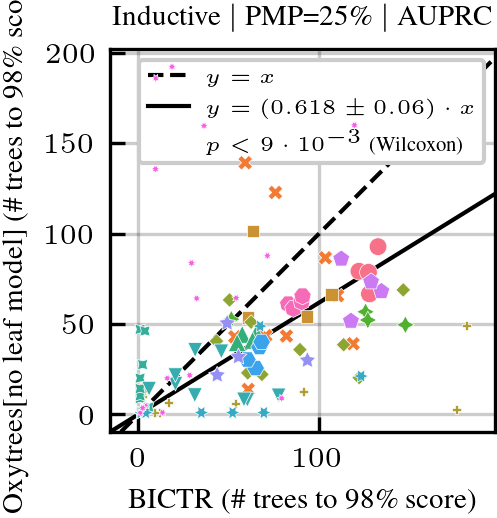

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=22.0, pvalue=0.0301513671875)
beta_hat=1.2426098680052546, se_beta=0.13620099176618294
linregress: LinregressResult(slope=0.9221193612690695, intercept=13.36594396281033, rvalue=0.6146005861227463, pvalue=0.014768444508607191, stderr=0.32825441221789314, intercept_stderr=12.469312121173646)


<Figure size 496.671x496.671 with 0 Axes>

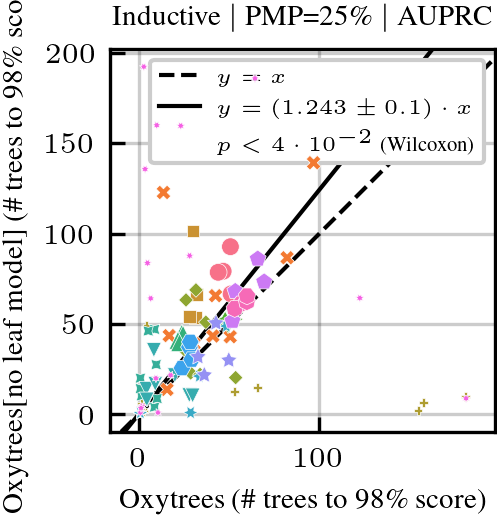

<Figure size 496.671x496.671 with 0 Axes>

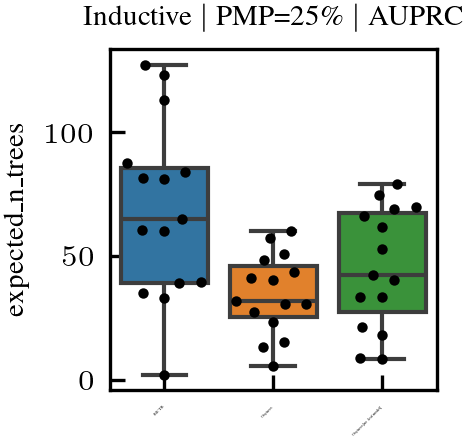

BICTR vs Oxytrees: WilcoxonResult(statistic=1.0, pvalue=0.0001220703125)
beta_hat=0.4947779997607743, se_beta=0.026534522221031663
linregress: LinregressResult(slope=0.4745795601668438, intercept=1.8731928772556898, rvalue=0.8778412523540154, pvalue=1.6932632910899708e-05, stderr=0.07181465710006091, intercept_stderr=6.154764353649776)


<Figure size 496.671x496.671 with 0 Axes>

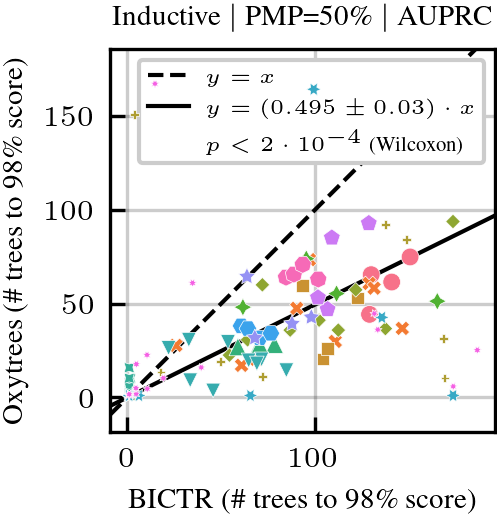

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=7.0, pvalue=0.00115966796875)
beta_hat=0.6444462517955916, se_beta=0.05226800105936447
linregress: LinregressResult(slope=0.5696682436303911, intercept=6.93487393513859, rvalue=0.7480272292538325, pvalue=0.0013410299041573498, stderr=0.1401792814503075, intercept_stderr=12.013848974986754)


<Figure size 496.671x496.671 with 0 Axes>

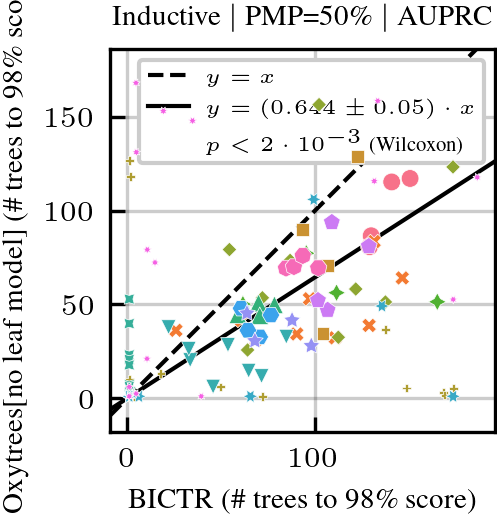

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=25.0, pvalue=0.04791259765625)
beta_hat=1.261615205669236, se_beta=0.11629535883360237
linregress: LinregressResult(slope=0.9758656678956492, intercept=13.545175445559941, rvalue=0.6927531031827106, pvalue=0.004198284561362354, stderr=0.28176071790316953, intercept_stderr=12.186000699580248)


<Figure size 496.671x496.671 with 0 Axes>

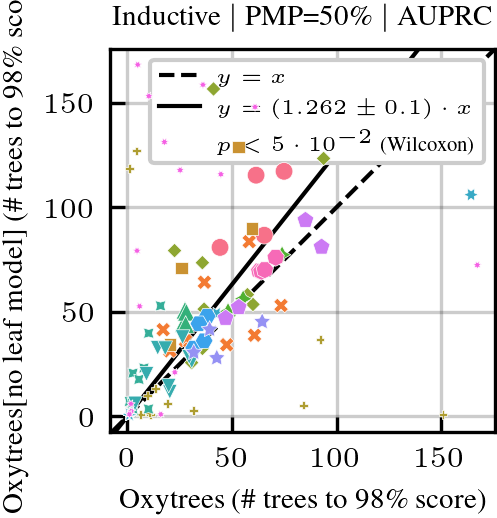

<Figure size 496.671x496.671 with 0 Axes>

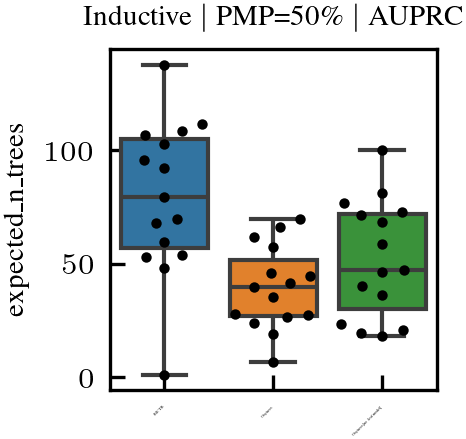

BICTR vs Oxytrees: WilcoxonResult(statistic=2.0, pvalue=0.00018310546875)
beta_hat=0.5716489355221015, se_beta=0.032193525683988304
linregress: LinregressResult(slope=0.5155642572075447, intercept=5.571329134755217, rvalue=0.8662211527899452, pvalue=2.9686915283029174e-05, stderr=0.08248170288463394, intercept_stderr=7.521051903647973)


<Figure size 496.671x496.671 with 0 Axes>

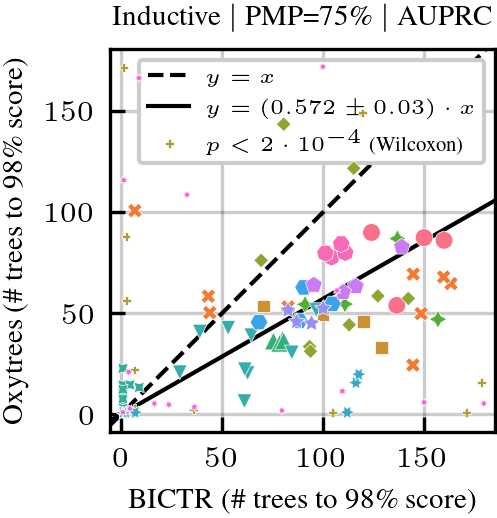

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=2.0, pvalue=0.00018310546875)
beta_hat=0.649398396897015, se_beta=0.03506155251589105
linregress: LinregressResult(slope=0.6281231889495761, intercept=2.113432571026763, rvalue=0.885355685367751, pvalue=1.1419999412881626e-05, stderr=0.09148044718599396, intercept_stderr=8.341597801601225)


<Figure size 496.671x496.671 with 0 Axes>

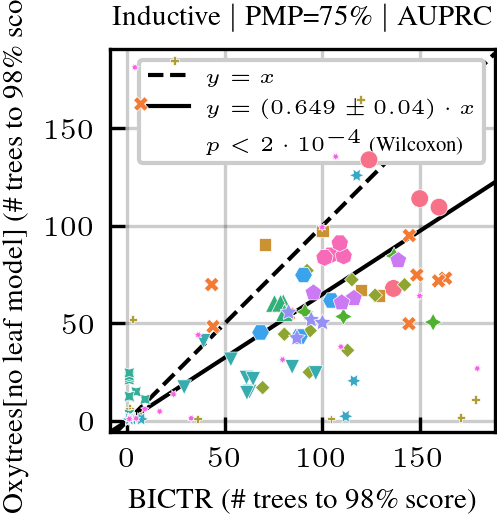

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=34.0, pvalue=0.15142822265625)
beta_hat=1.100834339889103, se_beta=0.07282153464270308
linregress: LinregressResult(slope=0.9904680079449567, intercept=6.427766226453464, rvalue=0.8309357078288103, pvalue=0.00012431974705035838, stderr=0.18393477547148107, intercept_stderr=9.79824152903472)


<Figure size 496.671x496.671 with 0 Axes>

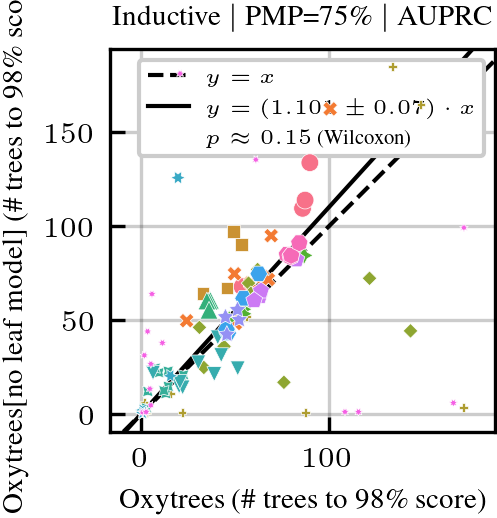

<Figure size 496.671x496.671 with 0 Axes>

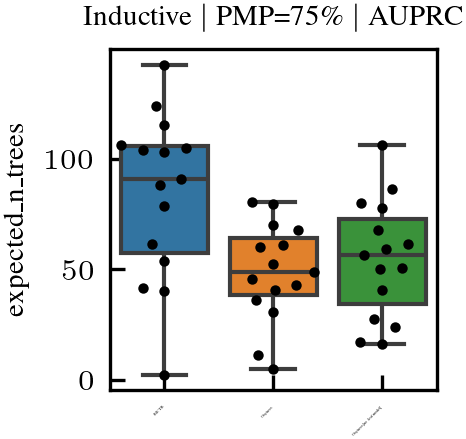

BICTR vs Oxytrees: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=0.4191022970662261, se_beta=0.029669020982205533
linregress: LinregressResult(slope=0.42129499785270724, intercept=-0.10292662503821681, rvalue=0.8549824123855538, pvalue=4.8749553719649854e-05, stderr=0.07088228051045181, intercept_stderr=2.99700791737774)


<Figure size 496.671x496.671 with 0 Axes>

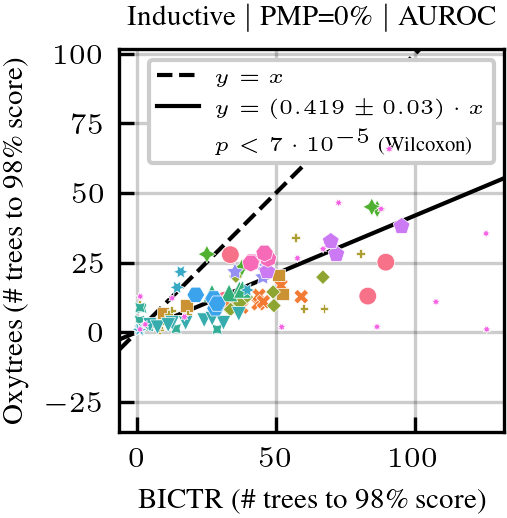

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=4.0, pvalue=0.00042724609375)
beta_hat=0.5351353759096819, se_beta=0.045870370052059135
linregress: LinregressResult(slope=0.4244253132260136, intercept=5.196793461312172, rvalue=0.7489162058173258, pvalue=0.001313657555829954, stderr=0.1041574204506699, intercept_stderr=4.4039301712121235)


<Figure size 496.671x496.671 with 0 Axes>

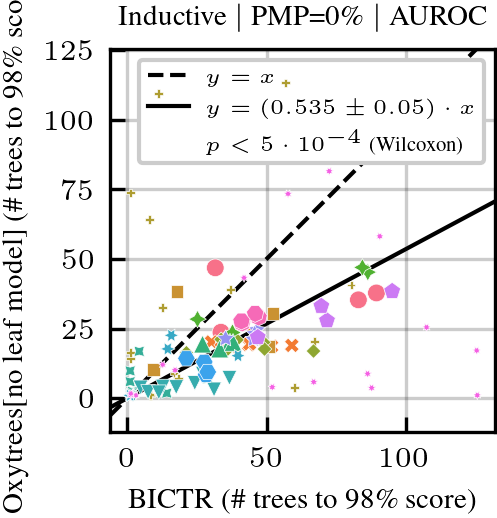

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=1.2176439245937585, se_beta=0.1187857595710648
linregress: LinregressResult(slope=0.8381746047009081, intercept=7.998761808452935, rvalue=0.7287785312214374, pvalue=0.002056123771133263, stderr=0.2184232997519272, intercept_stderr=4.003996857534712)


<Figure size 496.671x496.671 with 0 Axes>

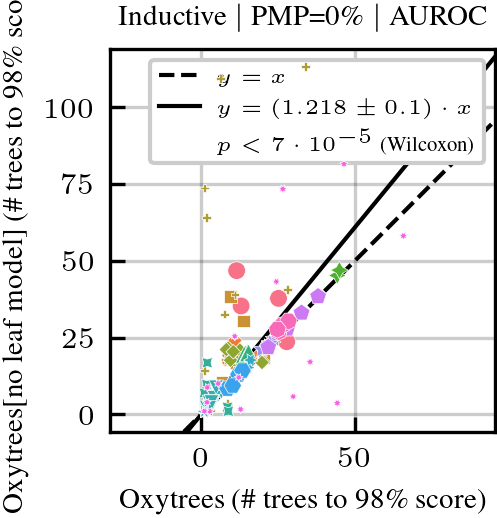

<Figure size 496.671x496.671 with 0 Axes>

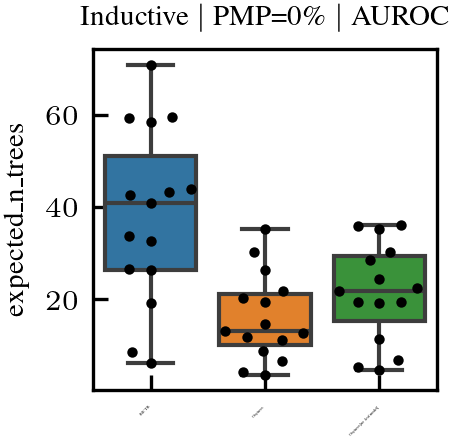

BICTR vs Oxytrees: WilcoxonResult(statistic=1.0, pvalue=0.0001220703125)
beta_hat=0.45957309691450776, se_beta=0.03489224949739539
linregress: LinregressResult(slope=0.507780998231807, intercept=-2.204097339976471, rvalue=0.8558942874333337, pvalue=4.6899152497627725e-05, stderr=0.08509457180183304, intercept_stderr=3.5320795757656516)


<Figure size 496.671x496.671 with 0 Axes>

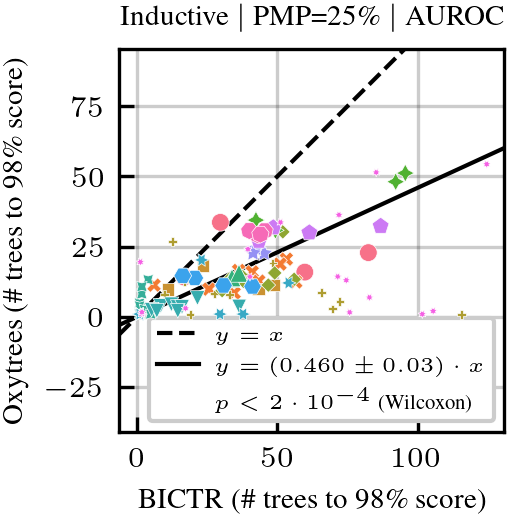

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=1.0, pvalue=0.0001220703125)
beta_hat=0.578013453823928, se_beta=0.02675271957732443
linregress: LinregressResult(slope=0.5679822465491936, intercept=0.4586334743234417, rvalue=0.922022919891147, pvalue=1.0212170994195044e-06, stderr=0.0661430372421254, intercept_stderr=2.745445049844948)


<Figure size 496.671x496.671 with 0 Axes>

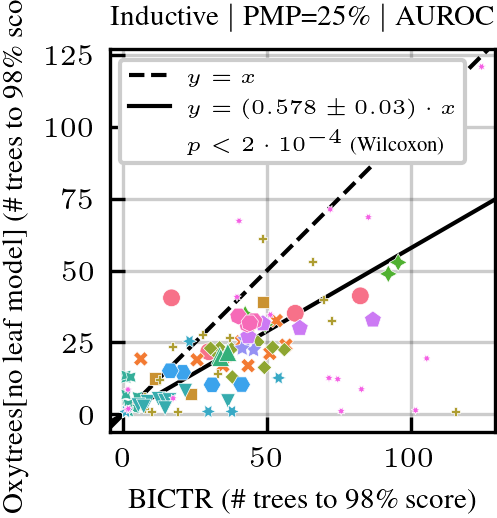

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=1.0, pvalue=0.0001220703125)
beta_hat=1.1950710597965126, se_beta=0.07532536252375906
linregress: LinregressResult(slope=0.936427396601003, intercept=6.007611477245678, rvalue=0.901856384825739, pvalue=4.333191992052527e-06, stderr=0.1244184927602286, intercept_stderr=2.467293714691955)


<Figure size 496.671x496.671 with 0 Axes>

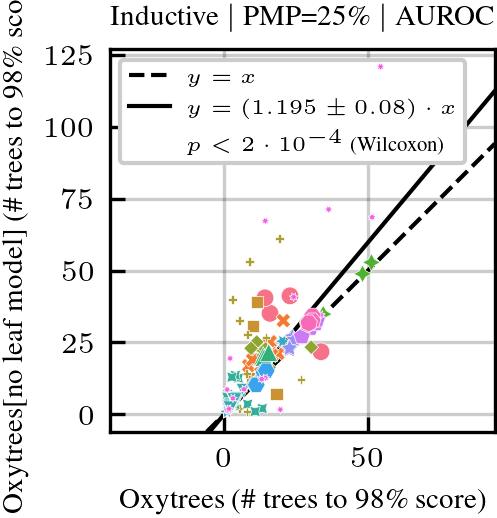

<Figure size 496.671x496.671 with 0 Axes>

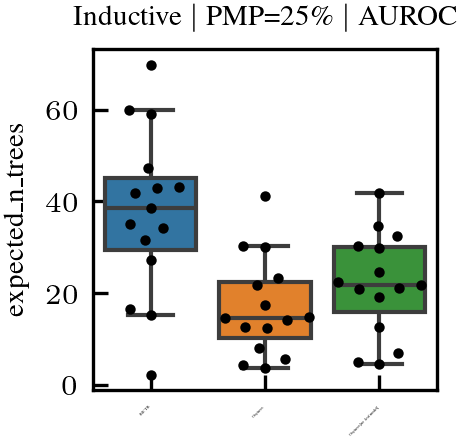

BICTR vs Oxytrees: WilcoxonResult(statistic=2.0, pvalue=0.00018310546875)
beta_hat=0.5222013443844096, se_beta=0.05180184836895338
linregress: LinregressResult(slope=0.443261389899079, intercept=3.6883672197654427, rvalue=0.7302133001399402, pvalue=0.001994055210785847, stderr=0.11502667860269428, intercept_stderr=4.780414275457608)


<Figure size 496.671x496.671 with 0 Axes>

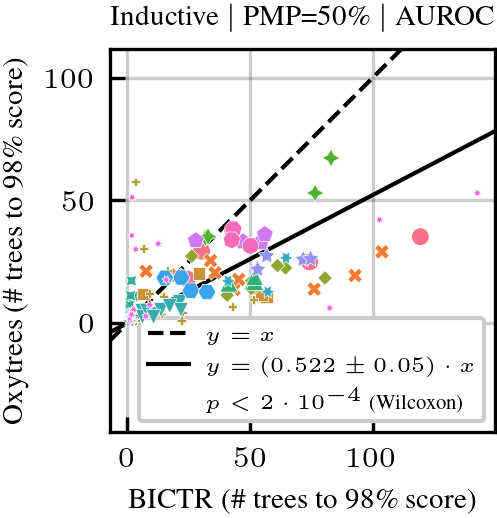

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=6.0, pvalue=0.0008544921875)
beta_hat=0.6552907140467338, se_beta=0.05045334334111579
linregress: LinregressResult(slope=0.5602954542884064, intercept=4.438530582011282, rvalue=0.8145390504619522, pvalue=0.0002175697156476964, stderr=0.11067331329500377, intercept_stderr=4.599491989289135)


<Figure size 496.671x496.671 with 0 Axes>

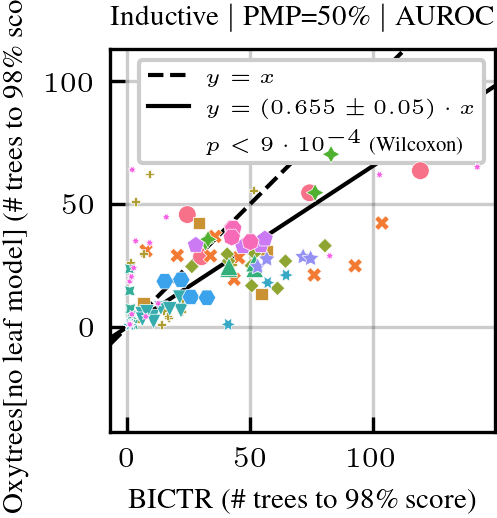

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=10.0, pvalue=0.00262451171875)
beta_hat=1.1944310074062423, se_beta=0.0718165585282627
linregress: LinregressResult(slope=1.0172170391544584, intercept=4.730775996943024, rvalue=0.897673908408757, pvalue=5.624813462536427e-06, stderr=0.1384928441648441, intercept_stderr=3.2059650422188035)


<Figure size 496.671x496.671 with 0 Axes>

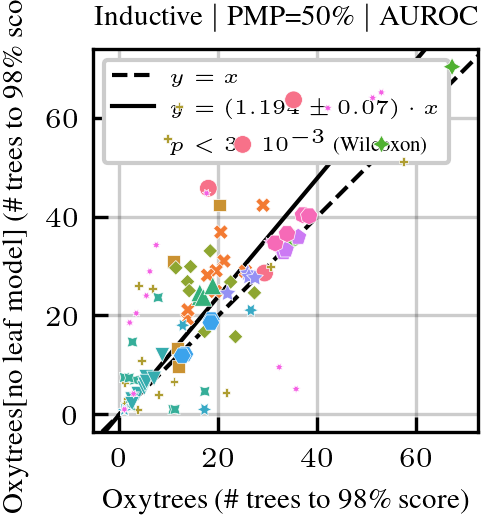

<Figure size 496.671x496.671 with 0 Axes>

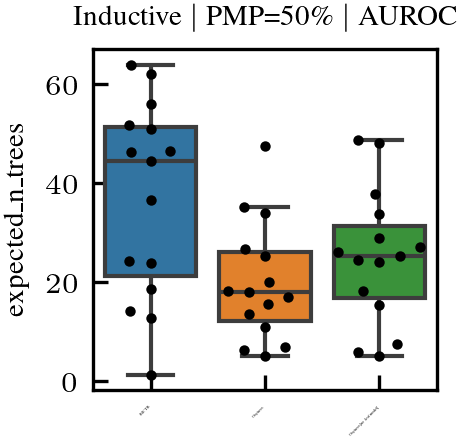

BICTR vs Oxytrees: WilcoxonResult(statistic=6.0, pvalue=0.0008544921875)
beta_hat=0.6683225124129613, se_beta=0.0586298099918927
linregress: LinregressResult(slope=0.5917816206919647, intercept=3.6269236443058723, rvalue=0.7816767916372281, pvalue=0.0005769771531948411, stderr=0.13095647993384915, intercept_stderr=5.519282670983163)


<Figure size 496.671x496.671 with 0 Axes>

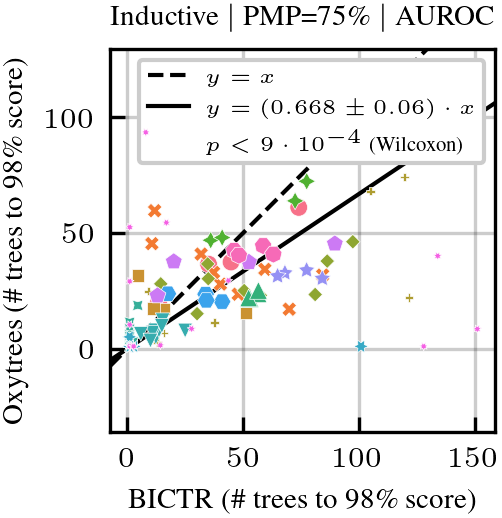

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=25.0, pvalue=0.04791259765625)
beta_hat=0.7545593595095881, se_beta=0.0784427157862408
linregress: LinregressResult(slope=0.6430788223960595, intercept=5.282554028908166, rvalue=0.714451678854873, pvalue=0.002765156218060952, stderr=0.1746715204858082, intercept_stderr=7.361693721598076)


<Figure size 496.671x496.671 with 0 Axes>

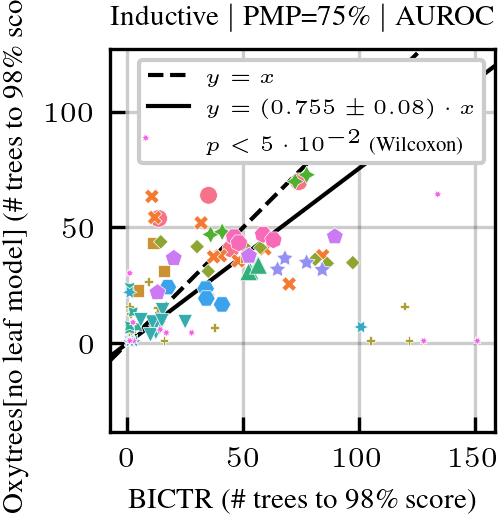

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=24.0, pvalue=0.041259765625)
beta_hat=1.1320071679880184, se_beta=0.05568008277737147
linregress: LinregressResult(slope=1.111207979265765, intercept=0.7082327491720477, rvalue=0.9346268638393785, pvalue=3.3485429897310336e-07, stderr=0.11726912438005349, intercept_stderr=3.4765230037382553)


<Figure size 496.671x496.671 with 0 Axes>

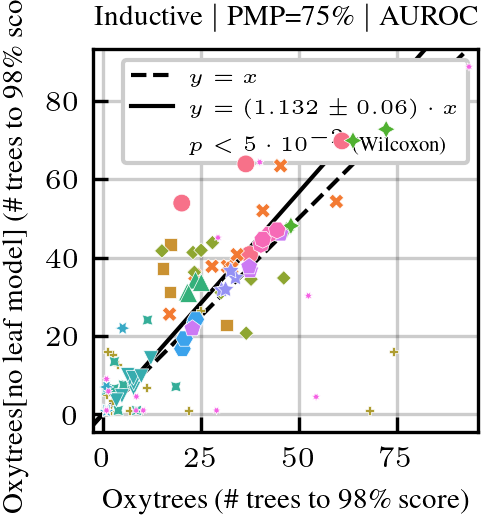

<Figure size 496.671x496.671 with 0 Axes>

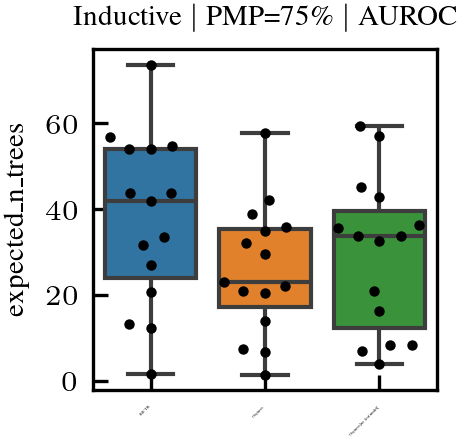

BICTR vs Oxytrees: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=0.5589685214432066, se_beta=0.046887906141455216
linregress: LinregressResult(slope=0.7611474884955932, intercept=-10.250606589414659, rvalue=0.8539590909243202, pvalue=5.089755592929977e-05, stderr=0.128631523555578, intercept_stderr=6.125778238595942)


<Figure size 496.671x496.671 with 0 Axes>

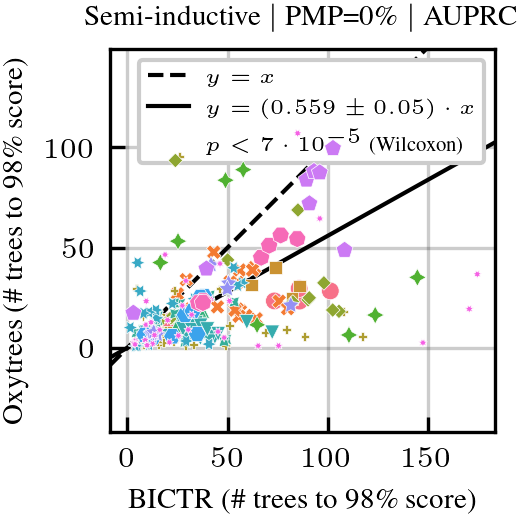

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=47.0, pvalue=0.48870849609375)
beta_hat=0.9357413322480019, se_beta=0.08422778078004133
linregress: LinregressResult(slope=0.6153420019263341, intercept=16.2444567529536, rvalue=0.5851367710664159, pvalue=0.02193860443534232, stderr=0.23652297613296258, intercept_stderr=11.263858656678561)


<Figure size 496.671x496.671 with 0 Axes>

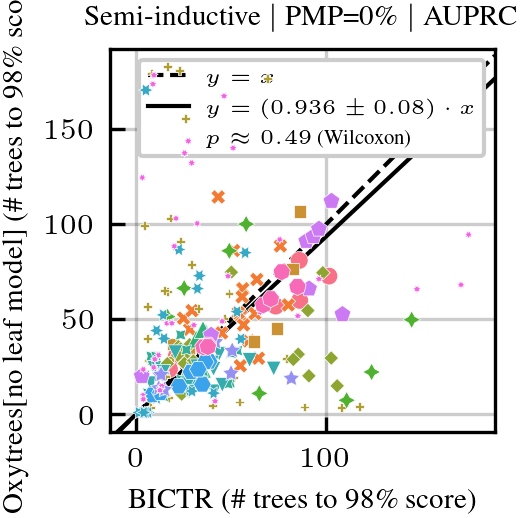

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=1.5080352648034452, se_beta=0.20112877517369065
linregress: LinregressResult(slope=0.623644863172029, intercept=28.928970872497253, rvalue=0.5285790337390284, pvalue=0.04279374915205882, stderr=0.2777820231860529, intercept_stderr=7.7500965744903505)


<Figure size 496.671x496.671 with 0 Axes>

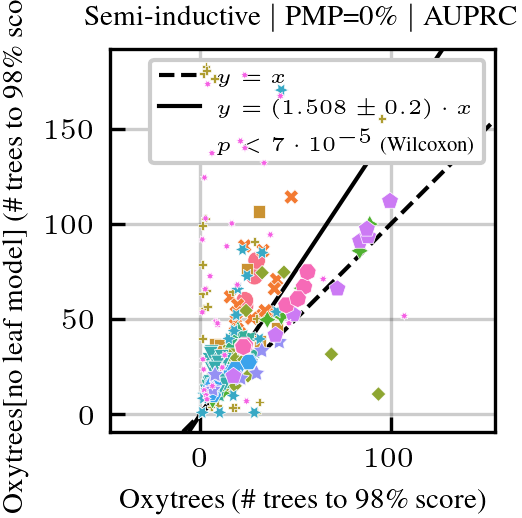

<Figure size 496.671x496.671 with 0 Axes>

c:\appsecurityexcluded\bipartite_forests_paper\experiments\env_new\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


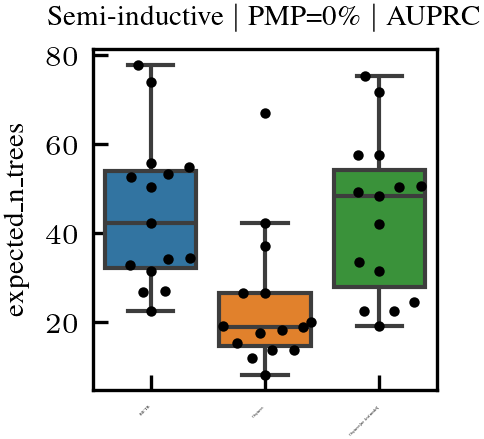

BICTR vs Oxytrees: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=0.6407514124898819, se_beta=0.05167621864151732
linregress: LinregressResult(slope=0.8652058790694213, intercept=-11.181542429182464, rvalue=0.8452497020055184, pvalue=7.254938520301635e-05, stderr=0.1517071599782953, intercept_stderr=7.1490914515447965)


<Figure size 496.671x496.671 with 0 Axes>

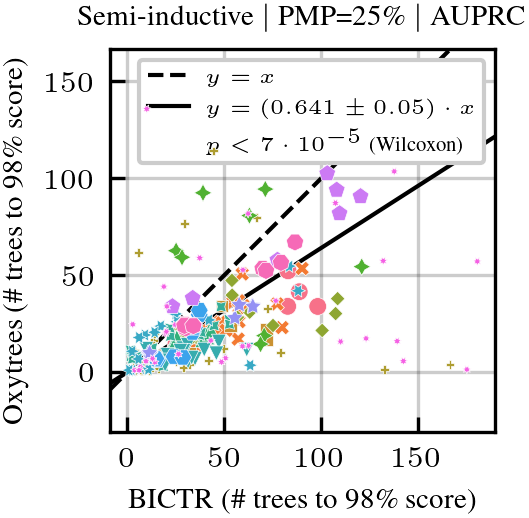

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=48.0, pvalue=0.52447509765625)
beta_hat=1.0407665160361164, se_beta=0.05051201679925941
linregress: LinregressResult(slope=1.029504041119462, intercept=0.5610574075769108, rvalue=0.8702774809126398, pvalue=2.4551365928561994e-05, stderr=0.1616066928193764, intercept_stderr=7.6155998590489995)


<Figure size 496.671x496.671 with 0 Axes>

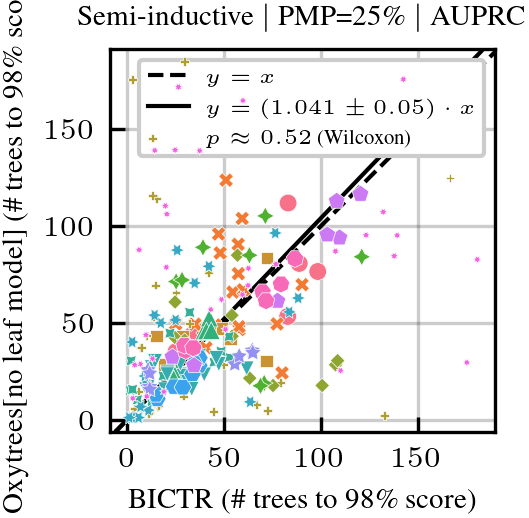

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=1.487470768383414, se_beta=0.14275289029124494
linregress: LinregressResult(slope=0.8477087946997498, intercept=23.23743811707692, rvalue=0.7335180658938518, pvalue=0.0018568030990744264, stderr=0.21785236048762469, intercept_stderr=6.871017367735871)


<Figure size 496.671x496.671 with 0 Axes>

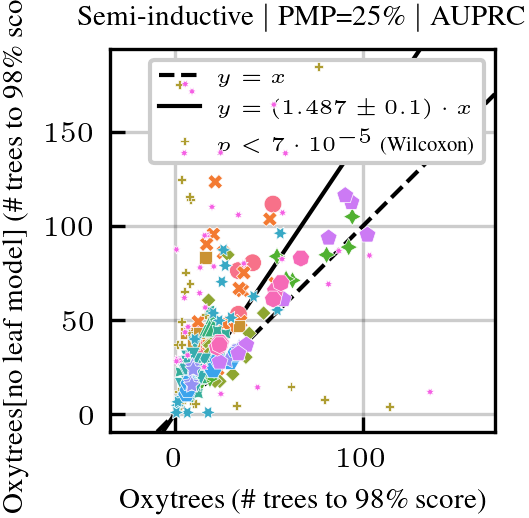

<Figure size 496.671x496.671 with 0 Axes>

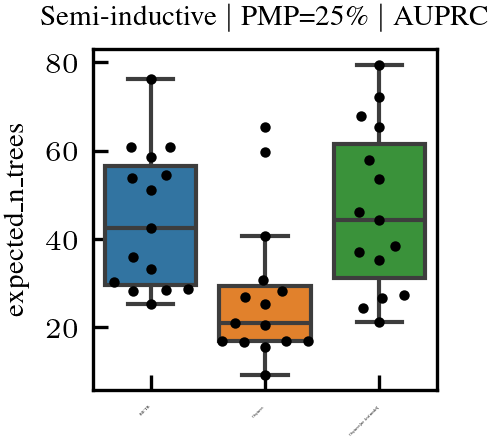

BICTR vs Oxytrees: WilcoxonResult(statistic=5.0, pvalue=0.0006103515625)
beta_hat=0.6135947028763138, se_beta=0.06934998197492201
linregress: LinregressResult(slope=0.5319195503110804, intercept=4.47192996597871, rvalue=0.5444560189614778, pvalue=0.03586489336307506, stderr=0.22728166514076953, intercept_stderr=11.8111058963994)


<Figure size 496.671x496.671 with 0 Axes>

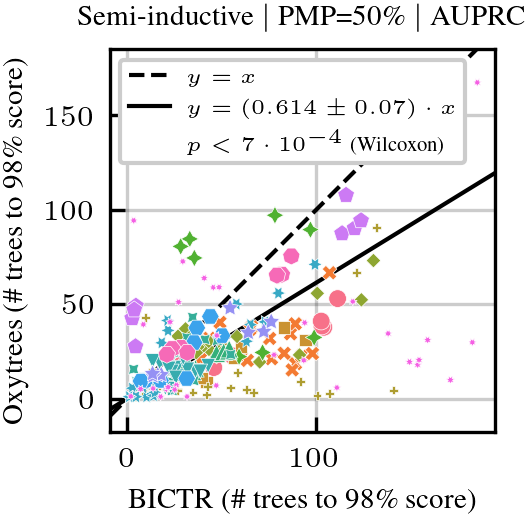

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=59.0, pvalue=0.97796630859375)
beta_hat=0.9813690217974043, se_beta=0.05520981939222825
linregress: LinregressResult(slope=0.7055844165156299, intercept=15.099934334743452, rvalue=0.7681554263822208, pvalue=0.0008230710172929521, stderr=0.16311236636796922, intercept_stderr=8.476431352221734)


<Figure size 496.671x496.671 with 0 Axes>

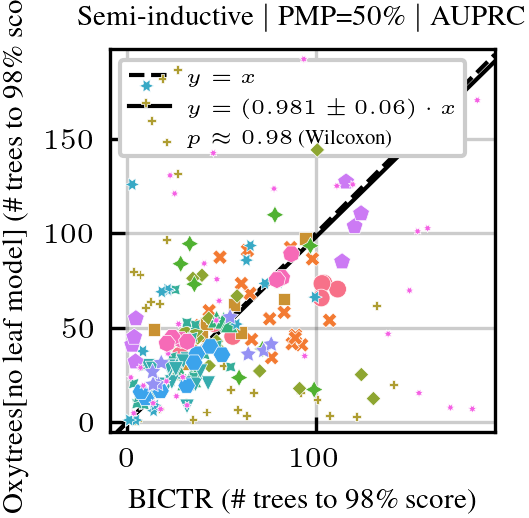

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
beta_hat=1.4178716956890578, se_beta=0.1351529571899461
linregress: LinregressResult(slope=0.6536482882557985, intercept=29.829285462331207, rvalue=0.6952282325766792, pvalue=0.004010034732449163, stderr=0.18743319447186937, intercept_stderr=6.489050605998361)


<Figure size 496.671x496.671 with 0 Axes>

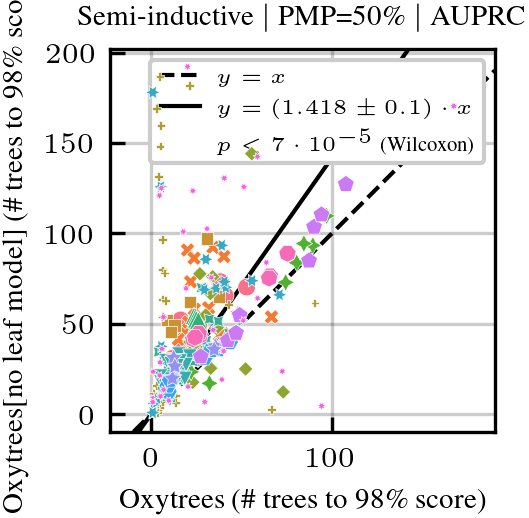

<Figure size 496.671x496.671 with 0 Axes>

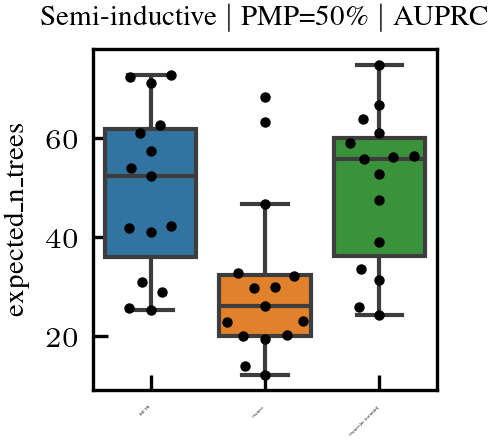

BICTR vs Oxytrees: WilcoxonResult(statistic=14.0, pvalue=0.0067138671875)
beta_hat=0.7331080407285249, se_beta=0.07609517688553084
linregress: LinregressResult(slope=0.7357545988654881, intercept=-0.152640758149154, rvalue=0.6030149861080906, pvalue=0.01733049766546605, stderr=0.2699535551978117, intercept_stderr=14.888589522632845)


<Figure size 496.671x496.671 with 0 Axes>

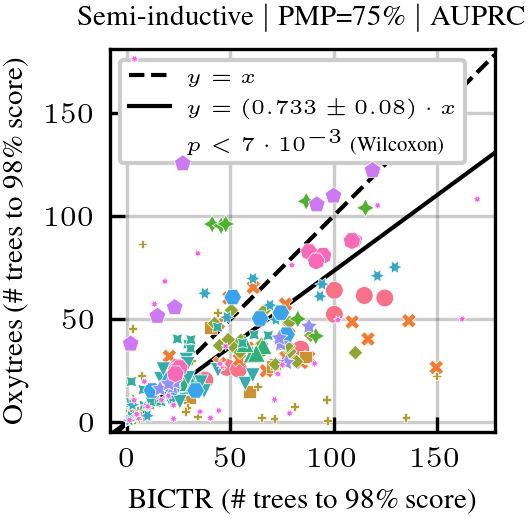

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=59.0, pvalue=0.97796630859375)
beta_hat=1.0314173800391675, se_beta=0.06606504833998797
linregress: LinregressResult(slope=0.916256056210582, intercept=6.641951874454314, rvalue=0.7385526334939647, pvalue=0.0016623968414059866, stderr=0.23197959635757323, intercept_stderr=12.794234123951847)


<Figure size 496.671x496.671 with 0 Axes>

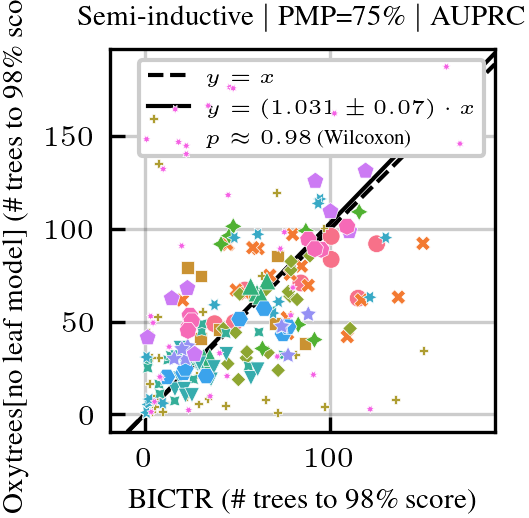

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=5.0, pvalue=0.0006103515625)
beta_hat=1.2812222767103607, se_beta=0.11251201364734906
linregress: LinregressResult(slope=0.7381230456309485, intercept=26.436051879667875, rvalue=0.7259358391970093, pvalue=0.002183678970942366, stderr=0.19395335567196698, intercept_stderr=8.412723055588353)


<Figure size 496.671x496.671 with 0 Axes>

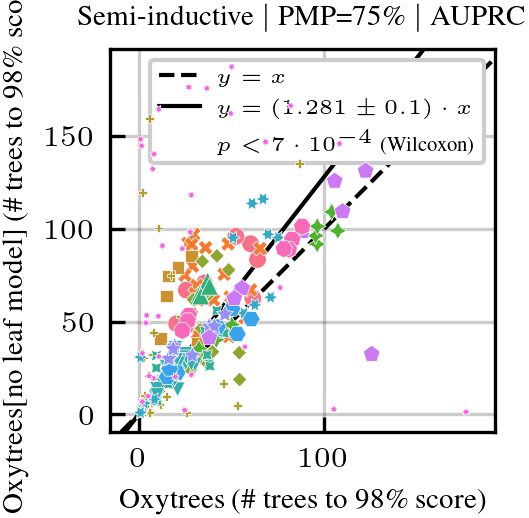

<Figure size 496.671x496.671 with 0 Axes>

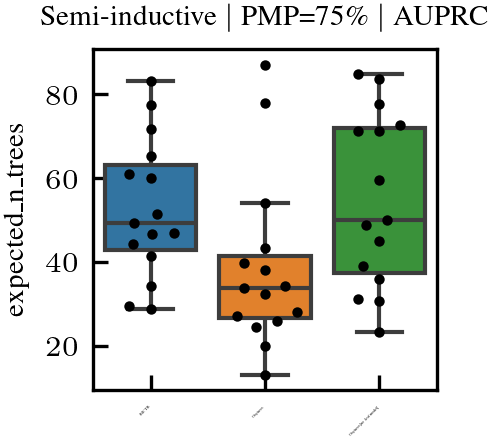

BICTR vs Oxytrees: WilcoxonResult(statistic=20.0, pvalue=0.02154541015625)
beta_hat=0.7184797314246278, se_beta=0.08350213556692869
linregress: LinregressResult(slope=0.5382461474186148, intercept=2.6013844924551526, rvalue=0.5910020761812952, pvalue=0.02033457487801575, stderr=0.20375870518169908, intercept_stderr=2.6814909443434716)


<Figure size 496.671x496.671 with 0 Axes>

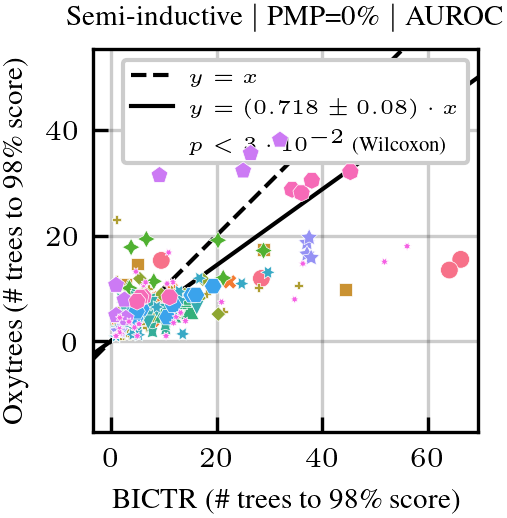

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=39.0, pvalue=0.25238037109375)
beta_hat=1.0400711814232493, se_beta=0.09348007788849085
linregress: LinregressResult(slope=0.6543251170760798, intercept=5.567629558899833, rvalue=0.6628142971917363, pvalue=0.007081318212810589, stderr=0.2050154063913666, intercept_stderr=2.6980292949894666)


<Figure size 496.671x496.671 with 0 Axes>

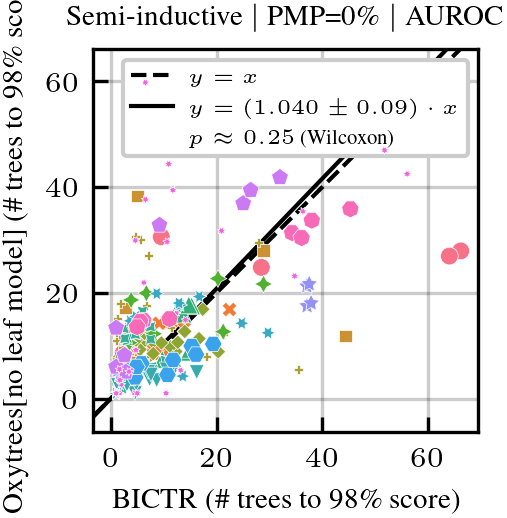

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=2.0, pvalue=0.00018310546875)
beta_hat=1.3491872033442236, se_beta=0.10046059739581231
linregress: LinregressResult(slope=0.9021174170103103, intercept=5.245903294922638, rvalue=0.8322489720005765, pvalue=0.00011857209895054904, stderr=0.1666721212221794, intercept_stderr=1.7184901408560807)


<Figure size 496.671x496.671 with 0 Axes>

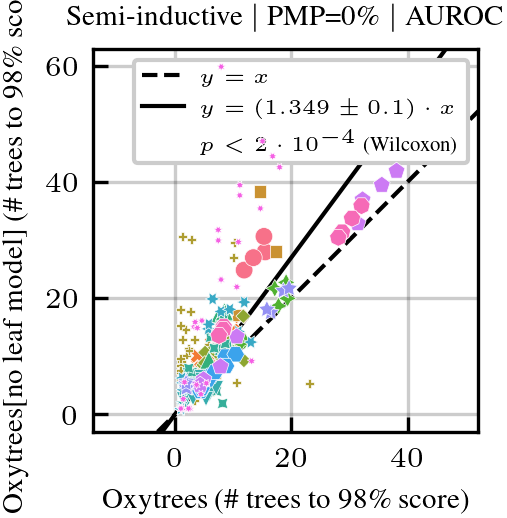

<Figure size 496.671x496.671 with 0 Axes>

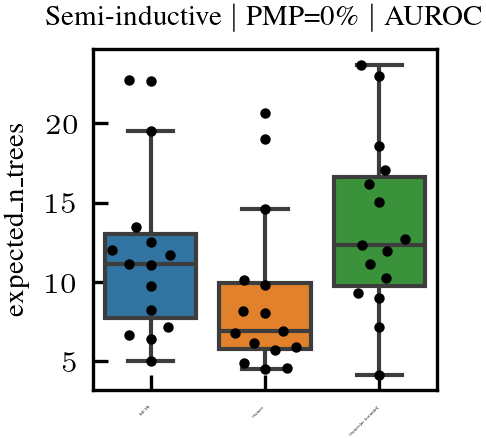

BICTR vs Oxytrees: WilcoxonResult(statistic=32.0, pvalue=0.12054443359375)
beta_hat=0.8618943773719743, se_beta=0.09632917526172625
linregress: LinregressResult(slope=0.7410793039656032, intercept=1.6717484362112938, rvalue=0.6114479815249677, pvalue=0.015434540789404745, stderr=0.2659905596456213, intercept_stderr=3.415830206787281)


<Figure size 496.671x496.671 with 0 Axes>

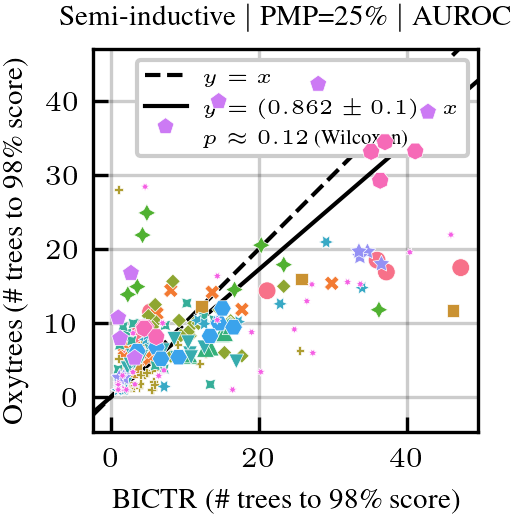

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=21.0, pvalue=0.02557373046875)
beta_hat=1.2019158457096102, se_beta=0.09830190542502738
linregress: LinregressResult(slope=0.8692298409539301, intercept=4.6034595892598436, rvalue=0.6866445341522365, pvalue=0.004693015520967141, stderr=0.2552474445491325, intercept_stderr=3.2778679531250847)


<Figure size 496.671x496.671 with 0 Axes>

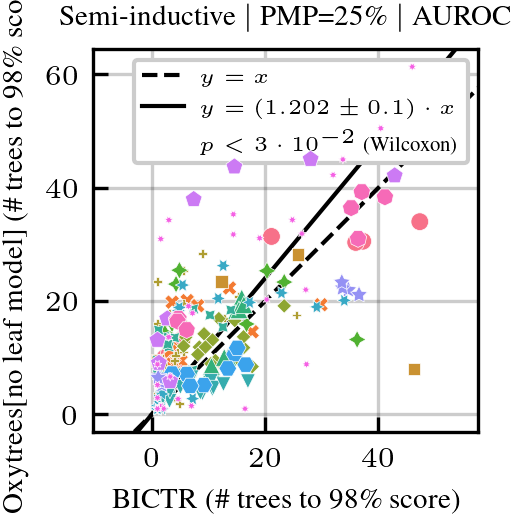

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=2.0, pvalue=0.00018310546875)
beta_hat=1.3051868994445082, se_beta=0.0872932256767233
linregress: LinregressResult(slope=0.913342882411288, intercept=5.369286210312836, rvalue=0.8744527702553313, pvalue=2.0057339740913104e-05, stderr=0.140529219062356, intercept_stderr=1.685959551056074)


<Figure size 496.671x496.671 with 0 Axes>

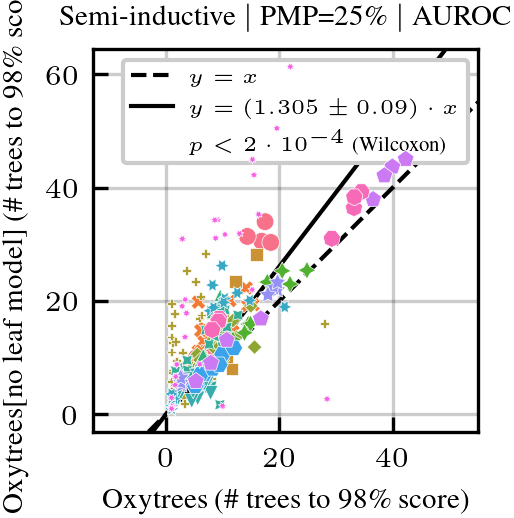

c:\appsecurityexcluded\bipartite_forests_paper\experiments\env_new\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Figure size 496.671x496.671 with 0 Axes>

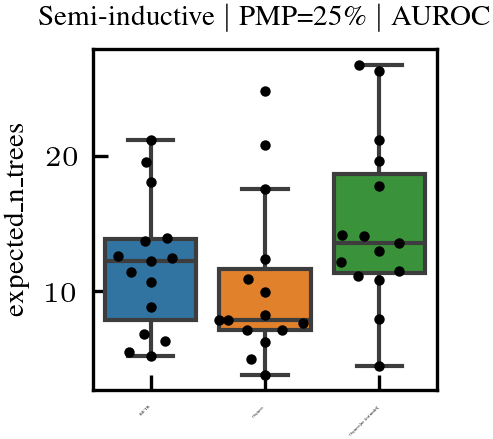

BICTR vs Oxytrees: WilcoxonResult(statistic=55.0, pvalue=0.803955078125)
beta_hat=0.97075658047395, se_beta=0.11959683743201494
linregress: LinregressResult(slope=0.7050672341881289, intercept=4.303819798448275, rvalue=0.5809230812113965, pvalue=0.023149250489323224, stderr=0.2739948913535566, intercept_stderr=3.9984847252835634)


<Figure size 496.671x496.671 with 0 Axes>

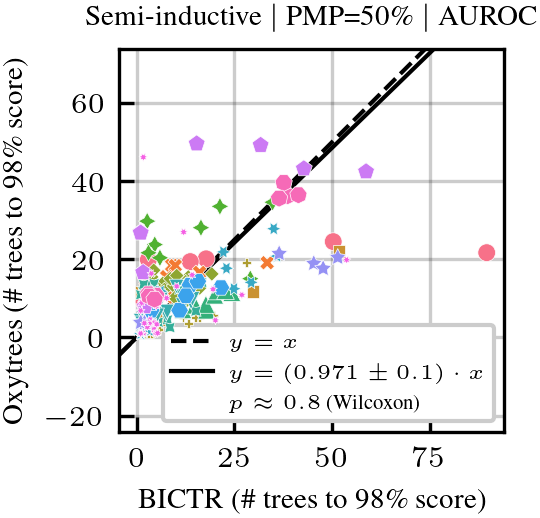

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=16.0, pvalue=0.01025390625)
beta_hat=1.2981672150024337, se_beta=0.12515010499350848
linregress: LinregressResult(slope=0.8402265874932675, intercept=7.418039024671856, rvalue=0.6618783315194662, pvalue=0.007191571460736183, stderr=0.2639263153319083, intercept_stderr=3.8515511557230724)


<Figure size 496.671x496.671 with 0 Axes>

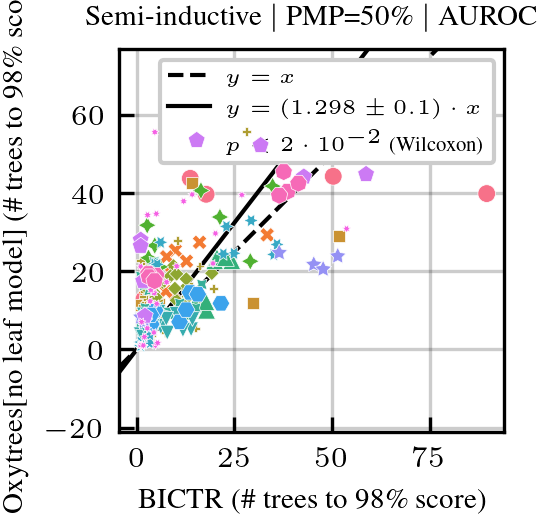

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=3.0, pvalue=0.00030517578125)
beta_hat=1.2621761387807664, se_beta=0.07256164047545863
linregress: LinregressResult(slope=0.9561362622694995, intercept=5.4865333457460395, rvalue=0.9141415170554705, pvalue=1.8728034293252868e-06, stderr=0.11760162062577863, intercept_stderr=1.8344945706403695)


<Figure size 496.671x496.671 with 0 Axes>

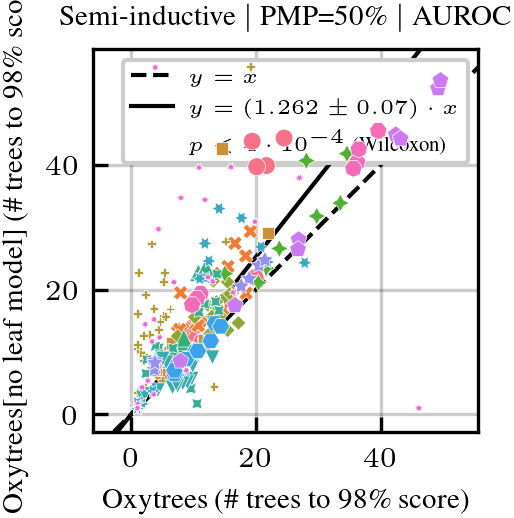

<Figure size 496.671x496.671 with 0 Axes>

c:\appsecurityexcluded\bipartite_forests_paper\experiments\env_new\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


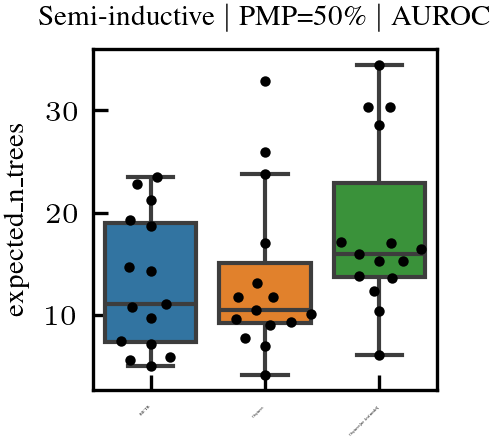

BICTR vs Oxytrees: WilcoxonResult(statistic=21.0, pvalue=0.02557373046875)
beta_hat=1.3107071008561961, se_beta=0.20900860562329834
linregress: LinregressResult(slope=0.49592198887718497, intercept=13.866095267768186, rvalue=0.3152178067930328, pvalue=0.2524580736411711, stderr=0.4141007483088944, intercept_stderr=6.303493161490443)


<Figure size 496.671x496.671 with 0 Axes>

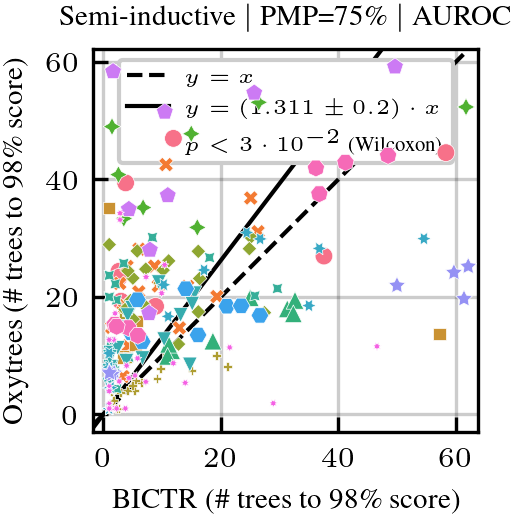

BICTR vs Oxytrees[no leaf model]: WilcoxonResult(statistic=7.0, pvalue=0.00115966796875)
beta_hat=1.5719366071498255, se_beta=0.20760865677307566
linregress: LinregressResult(slope=0.7235956346945616, intercept=14.437152287975056, rvalue=0.44515448972623944, pvalue=0.09635625281030413, stderr=0.40369807675552954, intercept_stderr=6.145142399590943)


<Figure size 496.671x496.671 with 0 Axes>

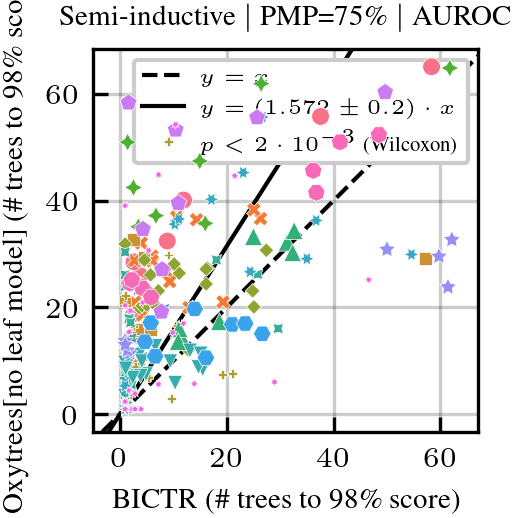

Oxytrees vs Oxytrees[no leaf model]: WilcoxonResult(statistic=10.0, pvalue=0.00262451171875)
beta_hat=1.1363421948572212, se_beta=0.045099058877524446
linregress: LinregressResult(slope=0.9817329718838821, intercept=4.047626428940976, rvalue=0.9501907953075899, pvalue=5.9396280905311396e-08, stderr=0.08931085291056205, intercept_stderr=2.0749821130340713)


<Figure size 496.671x496.671 with 0 Axes>

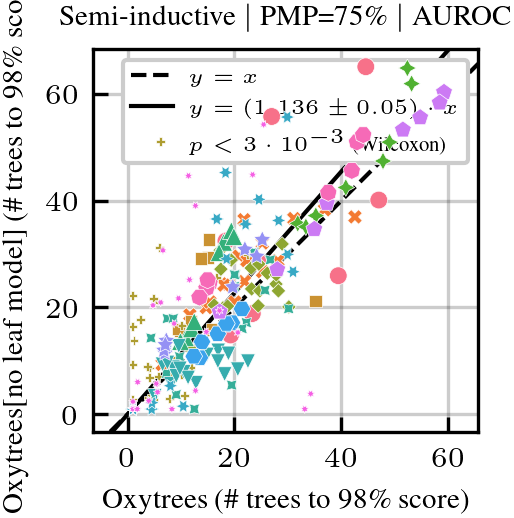

<Figure size 496.671x496.671 with 0 Axes>

c:\appsecurityexcluded\bipartite_forests_paper\experiments\env_new\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


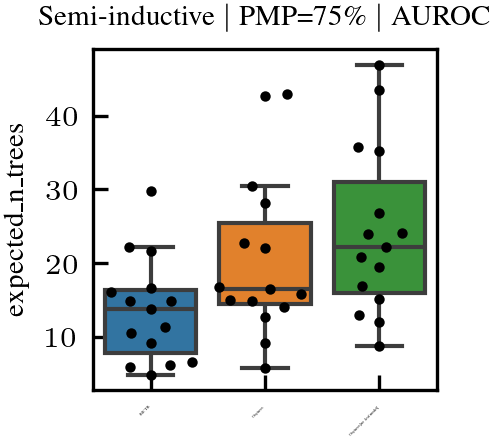

<Figure size 496.671x496.671 with 0 Axes>

In [15]:
import itertools

title_template = "{validation_setting} $\\mid$ PMP={masking_percent:.0f}\\% $\\mid$ {metric}"
fold_averaged_n_trees = interpolated_n_trees
# fold_averaged_n_trees = interpolated_n_trees.groupby(
#     interpolated_n_trees.index.droplevel("fold_name").names
# ).mean()
DIR_FIGURES.mkdir(parents=True, exist_ok=True)

for name, group in fold_averaged_n_trees.xs(
    0.98, level="target_score", drop_level=False
).groupby(level=["validation_setting", "metric", "target_score", "masking_percent"]):

    validation_setting, metric, target_score, masking_percent = name

    fold_average = group.groupby(group.index.droplevel("fold_name").names).mean()
    title = title_template.format(
        validation_setting=validation_setting,
        masking_percent=masking_percent,
        metric=metric,
    )
    estimators = group.index.get_level_values("estimator").unique()

    for e1, e2 in itertools.combinations(estimators, 2):
        e1_values = fold_average.xs(e1, level="estimator")
        e2_values = fold_average.xs(e2, level="estimator").loc[e1_values.index]
        stats_result = stats.wilcoxon(e1_values.values, e2_values.values)
        assert not e1_values.index.get_level_values("dataset").duplicated().any()
        print(f"{e1} vs {e2}: {stats_result}")

        x, y = e1_values.values, e2_values.values

        # Force model through origin: y = beta * x
        beta_hat = np.sum(x * y) / np.sum(x**2)
        # Residuals
        residuals = y - beta_hat * x
        n = len(x)
        # Estimate variance of residuals
        sigma_squared = np.sum(residuals**2) / (n - 1)
        # Standard error of beta_hat
        se_beta = np.sqrt(sigma_squared / np.sum(x**2))
        print(f"{beta_hat=}, {se_beta=}")

        linreg = stats.linregress(e1_values, e2_values)
        print("linregress:", linreg)

        plt.figure(figsize=(HALF_COLUMN_WIDTH,) * 2)
        plt.gca().axis("equal")

        unstacked = group.unstack("estimator").reset_index()
        unstacked["n_points_per_dataset"] = -unstacked.groupby("dataset").transform("size")

        sns.scatterplot(
            data=unstacked,
            x=e1,
            y=e2,
            style="dataset",
            hue="dataset",
            size="n_points_per_dataset",
            zorder=10,
            legend=None,
        )
        # plt.axline((0, 0), slope=1, color="k", linestyle="--", label="x = y")
        plt.axline(
            (0, 0),
            slope=1,
            color="k",
            linestyle="--",
            # label=f"$x = y \\mid {format_p_value(stats_result.pvalue)}$",
            label=f"$y = x$",
        )
        plt.axline(
            # (0, linreg.intercept),
            (0, 0),
            slope=beta_hat,
            color="k",
            linestyle="-",
            # label=f"$y = ({linreg.slope:.2f} \\pm {linreg.stderr:.2f}) \\cdot x$",
            label=f"$y = ({beta_hat:.3f} \\pm {se_beta:.1g}) \\cdot x$",
            # " \\mid {format_p_value(linreg.pvalue)}$",
        )

        # Create empty plot with blank marker containing the extra label
        plt.plot(
            [], [], " ", label=f"${format_p_value(stats_result.pvalue)}$ (Wilcoxon)"
        )

        # axlabel_suffix = " (N. of trees to 98% of final score)"
        axlabel_suffix = r" (\# trees to 98\% score)"

        plt.xlabel(e1 + axlabel_suffix)
        plt.ylabel(e2 + axlabel_suffix)
        plt.title(title)
        plt.grid()
        # plt.legend().set_visible(False)
        plt.legend(framealpha=1)

        plt.savefig(
            DIR_FIGURES
            / f"{validation_setting}_{metric}_{masking_percent:02.0f}_{e1}_{e2}.pdf",
        )
        plt.show()
        plt.clf()

    plt.figure(figsize=(HALF_COLUMN_WIDTH,) * 2)

    fig = sns.boxplot(
        data=fold_average.reset_index(),
        x="estimator",
        y="expected_n_trees",
        hue="estimator",
        showfliers=False,
    )
    fig = sns.swarmplot(
        data=fold_average.reset_index(),
        x="estimator",
        y="expected_n_trees",
        marker=".",
        color="k",
    )
    plt.title(title)
    plt.xlabel(None)
    plt.xticks(rotation=45, ha="right", size=0)
    plt.tight_layout()
    plt.show()
    plt.clf()